# Automobile Loan Default Prediction

## Machine Learning Classification Project

### Objective

The objective of this project is to develop a machine learning classification system that predicts whether an automobile loan applicant is likely to default on the loan.

The project follows a complete end-to-end machine learning lifecycle:

1. Business Understanding
2. Data Understanding
3. Data Quality Assessment
4. Attribute Identification
5. Data Transformation
6. Exploratory Data Analysis (EDA)
7. Statistical Analysis
8. Feature Engineering
9. Feature Selection
10. Train-Test Split
11. Data Preprocessing
12. Baseline Model
13. Machine Learning Model Development
14. Model Comparison and Evaluation
15. Class Imbalance Handling
16. Hyperparameter Tuning
17. Probability Threshold Optimization
18. Model Explainability
19. Business Interpretation
20. Final Conclusion

The final objective is not only to achieve good predictive performance, but also to develop a model whose predictions can be interpreted from a credit-risk perspective.

## 1. Problem Statement

Financial institutions provide loans to customers based on their financial profile, credit history, employment characteristics, demographic information, and other application-level attributes.

A loan default creates financial loss for the lending institution. Therefore, identifying customers who have a higher probability of default before approving a loan can help the institution improve credit-risk management.

### Machine Learning Problem

This project formulates loan default prediction as a **binary classification problem**.

The target variable is:

- `Default = 0` → Customer does not default
- `Default = 1` → Customer defaults

### Objective

Build and evaluate machine learning classification models that can estimate the probability that a loan applicant will default.

### Business Goal

The model should help answer:

> "Given the information available at the time of loan application, how likely is this applicant to default?"

The model should therefore prioritize:

- Identification of potential defaulters
- Probability-based risk assessment
- Appropriate handling of class imbalance
- Reduction of false negatives
- Interpretability of important risk factors
- Prevention of data leakage

## 2. Why is this a Classification Problem?

The target variable `Default` contains two possible outcomes:

- `0` → Non-default
- `1` → Default

Since the model needs to predict one of two discrete classes, this is a **binary classification problem**.

Mathematically:

\[
Default \in \{0,1\}
\]

The machine learning model will estimate:

\[
P(Default = 1 \mid X)
\]

where `X` represents the characteristics of the loan applicant.

The output can therefore be interpreted as the probability or risk score of loan default.

In [19]:
# ============================================================
# CELL 4: IMPORT LIBRARIES
# ============================================================

from pathlib import Path

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display
from IPython.display import display

# Statistical tests
from scipy.stats import chi2_contingency
from scipy.stats import pointbiserialr

# Machine Learning
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV
)

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    OrdinalEncoder,
    MinMaxScaler
)

from sklearn.impute import SimpleImputer

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Baseline and models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    HistGradientBoostingClassifier
)

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

# Feature selection
from sklearn.feature_selection import (
    mutual_info_classif,
    SelectKBest,
    chi2
)

# Reproducibility
RANDOM_STATE = 42

# Target and identifier
TARGET = "Default"
ID_COLUMN = "ID"

# Visualization settings
sns.set_theme(style="whitegrid")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("All libraries imported successfully.")
print(f"Random State: {RANDOM_STATE}")
print(f"Target Variable: {TARGET}")

All libraries imported successfully.
Random State: 42
Target Variable: Default


## 3. Dataset Source

The dataset used in this project is an automobile loan default dataset derived from the Kaggle **Automobile Loan Default** dataset.

A representative dataset containing 121k records is used for this project.

The dataset contains customer demographic information, financial information, employment characteristics, credit-related information, loan information, and application attributes.

The target variable is `Default`.

In [20]:
# ============================================================
# CELL 6: LOAD DATASET
# ============================================================

DATA_DIR = Path("./dataset")
TRAIN_PATH = DATA_DIR / "Loan_Default_Representative_6000.csv"
TEST_PATH = DATA_DIR / "Test_Dataset.csv"
DICTIONARY_PATH = DATA_DIR / "Data_Dictionary.csv"


df = pd.read_csv(
    TRAIN_PATH,
    low_memory=False
)

data_dictionary = pd.read_csv(
    DICTIONARY_PATH
)

print("Dataset loaded successfully.")
print()
print(f"Number of rows    : {df.shape[0]:,}")
print(f"Number of columns : {df.shape[1]:,}")

Dataset loaded successfully.

Number of rows    : 6,000
Number of columns : 40


## 4. Initial Dataset Understanding

Before performing any preprocessing or modelling, it is important to understand the structure of the dataset.

We inspect:

- Number of observations
- Number of attributes
- Feature names
- Raw data types
- Unique values
- Missing values
- Target variable

This initial inspection helps identify potential data-quality issues before applying transformations.

An important principle followed in this project is:

> **Raw storage type should not automatically determine machine-learning feature type.**

For example, a variable stored as `float64` can still represent a categorical attribute.

For example:

`Car_Owned = 0 / 1`

represents:

- `0 = No`
- `1 = Yes`

Therefore, it is a **binary categorical feature**, even though Pandas may store it as a numerical column.

In [21]:
# ============================================================
# CELL 8: DATASET SHAPE AND SAMPLE RECORDS
# ============================================================

print("Dataset Shape")
print("=" * 60)
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]:,}")

print("\nFirst 5 Records")
print("=" * 60)

display(df.head())

Dataset Shape
Rows    : 6,000
Columns : 40

First 5 Records


,ID,Client_Income,Car_Owned,Bike_Owned,Active_Loan,House_Own,Child_Count,Credit_Amount,Loan_Annuity,Accompany_Client,Client_Income_Type,Client_Education,Client_Marital_Status,Client_Gender,Loan_Contract_Type,Client_Housing_Type,Population_Region_Relative,Age_Days,Employed_Days,Registration_Days,ID_Days,Own_House_Age,Mobile_Tag,Homephone_Tag,Workphone_Working,Client_Occupation,Client_Family_Members,Cleint_City_Rating,Application_Process_Day,Application_Process_Hour,Client_Permanent_Match_Tag,Client_Contact_Work_Tag,Type_Organization,Score_Source_1,Score_Source_2,Score_Source_3,Social_Circle_Default,Phone_Change,Credit_Bureau,Default
0,12200978,22500,0.0,1.0,1.0,1.0,0.0,63519.3,6201,Alone,Retired,Secondary,M,Male,CL,Home,0.032561,22827,365243,7688,NaN,NaN,1,0,1,NaN,2.0,1.0,0.0,10.0,Yes,Yes,XNA,NaN,0.742129,NaN,0.0722,1461.0,NaN,0
1,12106561,9000,1.0,0.0,1.0,1.0,1.0,13500.0,675,Alone,Govt Job,Secondary,M,Male,RL,Home,0.035792,8378,1525,329,1056,8.0,1,0,0,Accountants,3.0,2.0,2.0,10.0,Yes,Yes,Government,NaN,0.218044,0.454321,NaN,776.0,0.0,0
2,12203675,22500,0.0,0.0,1.0,0.0,NaN,90000.0,4500,Alone,Retired,Graduation,M,Male,RL,Home,0.025164,14367,365243,2292,4431,NaN,1,0,0,NaN,2.0,2.0,4.0,14.0,Yes,Yes,XNA,0.801654,0.567663,0.633032,0.1742,158.0,0.0,0
3,12103153,9450,0.0,0.0,1.0,1.0,2.0,17790.3,1251,Alone,Service,Secondary,W,Male,CL,Home,0.025164,14666,3974,7342,5285,NaN,1,0,0,Sales,3.0,2.0,2.0,12.0,Yes,Yes,Trade: type 1,NaN,0.511677,0.713631,NaN,1732.0,1.0,0
4,12175141,6750,1.0,1.0,1.0,0.0,1.0,90000.0,3813.3,Alone,Govt Job,Secondary,M,Male,CL,Home,0.01452,15066,8223,1470,4699,37.0,1,1,0,Medicine,3.0,2.0,2.0,10.0,Yes,Yes,Medicine,0.440522,0.582985,0.422370,NaN,889.0,1.0,0


In [22]:
# ============================================================
# CELL 9: COLUMN NAMES
# ============================================================

column_summary = pd.DataFrame({
    "Column_Number": range(1, len(df.columns) + 1),
    "Feature_Name": df.columns
})

display(column_summary)

,Column_Number,Feature_Name
0,1,ID
1,2,Client_Income
2,3,Car_Owned
3,4,Bike_Owned
4,5,Active_Loan
5,6,House_Own
6,7,Child_Count
7,8,Credit_Amount
8,9,Loan_Annuity
9,10,Accompany_Client


## 5. Data Dictionary and Attribute Semantics

A data dictionary is particularly important for this dataset because several attributes are represented using numeric codes.

For example:

- Binary indicators may be stored as integers/floats.
- Day-of-week may be represented by numeric codes.
- City rating may use values such as 1, 2 and 3.
- Some financial variables may initially be stored as strings.
- Special values may represent unavailable or non-applicable information.

Therefore, feature classification will be based on the **meaning of the attribute**, rather than only its Pandas data type.

This distinction is important because the preprocessing method depends on the attribute type.

In [23]:
# ============================================================
# CELL 11: DISPLAY DATA DICTIONARY
# ============================================================

print("Dataset Data Dictionary")
print("=" * 80)

display(data_dictionary)

Dataset Data Dictionary


,Variable,Description
0,ID,Client Loan application ID
1,Client_Income,Client Income in $
2,Car_Owned,Any Car owned by client before applying for th...
3,Bike_Owned,Any bike owned by client (0 means No and 1 mea...
4,Active_Loan,Any other active loan at the time of aplicatio...
5,House_Own,Any house owned by client (0 means No and 1 me...
6,Child_Count,Number of children the client has
7,Credit_Amount,Credit amount of the loan in $
8,Loan_Annuity,Loan annuity in $
9,Accompany_Client,Who accompanied the client when client applied...


## 6. Raw Data Types

The following analysis examines how Python currently represents each feature.

However, this is only a **storage-level classification**.

We will later create a separate **semantic feature classification** based on the meaning of each attribute.

This distinction prevents incorrect preprocessing.

For example:

`Car_Owned` may appear as `float64`, but it represents a Yes/No ownership status and should therefore be treated as categorical.

Similarly:

`Application_Process_Day` may be stored as a number, but a day code such as 1, 2, 3, etc. does not represent a continuous numerical quantity.

In [24]:
# ============================================================
# CELL 13: RAW DATA TYPE AUDIT
# ============================================================

raw_dtype_summary = pd.DataFrame({
    "Feature": df.columns,
    "Raw_Dtype": df.dtypes.astype(str).values,
    "Unique_Values": [
        df[col].nunique(dropna=True)
        for col in df.columns
    ],
    "Missing_Count": [
        df[col].isna().sum()
        for col in df.columns
    ],
    "Missing_Percentage": [
        df[col].isna().mean() * 100
        for col in df.columns
    ]
})

raw_dtype_summary["Missing_Percentage"] = (
    raw_dtype_summary["Missing_Percentage"]
    .round(2)
)

display(raw_dtype_summary)

,Feature,Raw_Dtype,Unique_Values,Missing_Count,Missing_Percentage
0,ID,int64,6000,0,0.00
1,Client_Income,object,226,178,2.97
2,Car_Owned,float64,2,174,2.90
3,Bike_Owned,float64,2,175,2.92
4,Active_Loan,float64,2,152,2.53
5,House_Own,float64,2,180,3.00
6,Child_Count,float64,7,166,2.77
7,Credit_Amount,float64,1393,189,3.15
8,Loan_Annuity,object,3003,231,3.85
9,Accompany_Client,object,7,103,1.72


## 7. Target Variable Analysis

The target variable is `Default`.

It is a binary variable:

| Value | Meaning |
|---|---|
| 0 | Non-default |
| 1 | Default |

Before building a classifier, we need to understand the distribution of the target.

This is particularly important for credit-risk datasets because default events are usually much less frequent than non-default events.

If the target is highly imbalanced, a model can achieve high accuracy simply by predicting the majority class.

Therefore, later in the project we will use additional metrics such as:

- Precision
- Recall
- F1-score
- ROC-AUC
- PR-AUC

rather than relying only on accuracy.

In [25]:
# ============================================================
# CELL 15: TARGET DISTRIBUTION
# ============================================================

target_counts = df[TARGET].value_counts().sort_index()
target_percentages = (
    df[TARGET]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

target_summary = pd.DataFrame({
    "Default": target_counts.index,
    "Count": target_counts.values,
    "Percentage": target_percentages.values.round(2)
})

display(target_summary)

default_rate = df[TARGET].mean() * 100

print(f"\nOverall default rate: {default_rate:.2f}%")

,Default,Count,Percentage
0,0,5518,91.97
1,1,482,8.03



Overall default rate: 8.03%


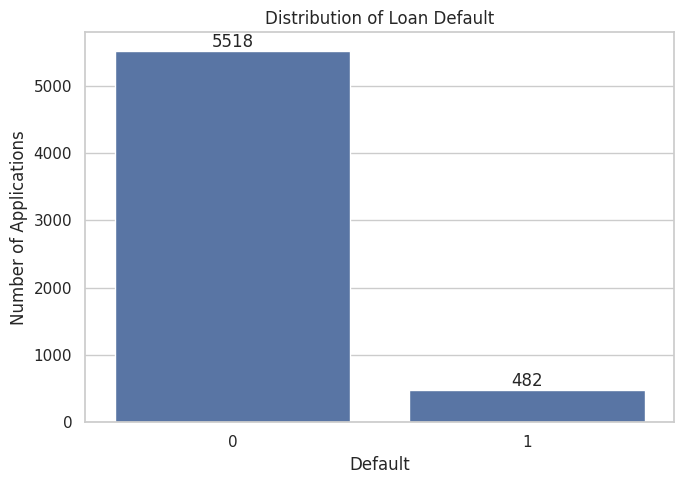

In [26]:
# ============================================================
# CELL 16: VISUALIZE TARGET DISTRIBUTION
# ============================================================

plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x=TARGET
)

plt.title("Distribution of Loan Default")
plt.xlabel("Default")
plt.ylabel("Number of Applications")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

### Interpretation

The target distribution shows that loan defaults represent a minority class in the dataset.

This creates a **class imbalance problem**.

Class imbalance is important because a model optimized only for accuracy may favor the majority class (`Default = 0`) and fail to identify actual defaulters.

For a credit-risk application, false negatives can be particularly important because:

> A false negative means that a customer who eventually defaults was incorrectly classified as a low-risk customer.

Therefore, later model evaluation will give particular attention to **Recall, F1-score and PR-AUC**, in addition to ROC-AUC and accuracy.

## 8. Inspect Object-Type Variables

Some columns are stored as strings even though they represent numerical quantities.

We should **not convert every object column to numeric**, because many object columns are genuine categorical variables.

For example:

- `Client_Gender` → categorical
- `Client_Education` → categorical
- `Client_Occupation` → categorical
- `Type_Organization` → categorical

On the other hand:

- `Client_Income`
- `Loan_Annuity`
- `Age_Days`
- `Employed_Days`

represent numerical quantities even if they are initially stored as text.

Therefore, conversion will be performed explicitly using the data dictionary.

In [27]:
# ============================================================
# CELL 19: IDENTIFY OBJECT-TYPE COLUMNS
# ============================================================

object_columns = df.select_dtypes(
    include="object"
).columns.tolist()

print("Object-type columns:")
print("=" * 70)

for col in object_columns:
    print(col)

print(f"\nTotal object-type columns: {len(object_columns)}")

Object-type columns:
Client_Income
Loan_Annuity
Accompany_Client
Client_Income_Type
Client_Education
Client_Marital_Status
Client_Gender
Loan_Contract_Type
Client_Housing_Type
Population_Region_Relative
Age_Days
Employed_Days
Registration_Days
ID_Days
Client_Occupation
Client_Permanent_Match_Tag
Client_Contact_Work_Tag
Type_Organization

Total object-type columns: 18


# 9. Attribute Identification

## Numerical vs Categorical Variables

Machine learning preprocessing should be based on the **semantic meaning of a feature**, not merely on its physical storage type.

A feature is considered numerical when its values represent a measurable quantity for which arithmetic operations are meaningful.

Examples:

- Income
- Loan amount
- Age
- Employment duration
- Credit score

A feature is considered categorical when its values represent distinct groups, labels, statuses, or codes.

Examples:

- Gender
- Housing type
- Education category
- Ownership status
- Day of the week

### Important Example: Car_Owned

`Car_Owned` is stored numerically as `0` and `1`.

However:

\[
0 = No
\]

\[
1 = Yes
\]

The difference between 0 and 1 does not represent a measurable quantity.

Therefore:

> **Car_Owned is a binary categorical variable, not a continuous numerical variable.**

The same principle is applied to other binary indicators.

### Important Example: Application_Process_Day

A day code is categorical because the numerical difference between two day codes does not represent a meaningful distance.

For example, treating:

`Monday = 1`

and

`Tuesday = 2`

as continuous values would incorrectly imply that Tuesday is numerically greater than Monday.

Therefore it is treated as categorical.

### Important Example: Cleint_City_Rating

This variable is an ordinal attribute because its values have a natural ordering.

For the initial model, it will be retained as a categorical/ordinal variable rather than assuming that the numerical distance between rating levels is necessarily proportional.

This classification will be used consistently throughout EDA, feature selection and model preprocessing.

In [28]:
# ============================================================
# CELL 21: SEMANTIC FEATURE CLASSIFICATION
# ============================================================

# ------------------------------------------------------------
# Binary categorical variables
# ------------------------------------------------------------
binary_categorical_features = [
    "Car_Owned",
    "Bike_Owned",
    "Active_Loan",
    "House_Own",
    "Homephone_Tag",
    "Workphone_Working",
    "Client_Permanent_Match_Tag",
    "Client_Contact_Work_Tag"
]


# ------------------------------------------------------------
# Nominal categorical variables
# ------------------------------------------------------------
nominal_categorical_features = [
    "Accompany_Client",
    "Client_Income_Type",
    "Client_Marital_Status",
    "Client_Gender",
    "Loan_Contract_Type",
    "Client_Housing_Type",
    "Client_Occupation",
    "Type_Organization"
]


# ------------------------------------------------------------
# Ordinal categorical variables
# ------------------------------------------------------------
ordinal_categorical_features = [
    "Client_Education",
    "Cleint_City_Rating"
]


# ------------------------------------------------------------
# Calendar categorical variables
# ------------------------------------------------------------
calendar_categorical_features = [
    "Application_Process_Day"
]


# ------------------------------------------------------------
# Numerical count variables
# ------------------------------------------------------------
count_numerical_features = [
    "Child_Count",
    "Client_Family_Members",
    "Credit_Bureau",
    "Social_Circle_Default"
]


# ------------------------------------------------------------
# Continuous numerical variables
# ------------------------------------------------------------
continuous_numerical_features = [
    "Credit_Amount",
    "Own_House_Age",
    "Score_Source_1",
    "Score_Source_2",
    "Score_Source_3",
    "Phone_Change"
]


# ------------------------------------------------------------
# Numerical variables currently stored as text
# ------------------------------------------------------------
numeric_text_features = [
    "Client_Income",
    "Loan_Annuity",
    "Population_Region_Relative",
    "Age_Days",
    "Employed_Days",
    "Registration_Days",
    "ID_Days"
]


# ------------------------------------------------------------
# Time feature
# ------------------------------------------------------------
time_features = [
    "Application_Process_Hour"
]


# ------------------------------------------------------------
# Target and identifier
# ------------------------------------------------------------
target_features = [
    TARGET
]

identifier_features = [
    ID_COLUMN
]


# Combine categorical features
categorical_features = (
    binary_categorical_features
    + nominal_categorical_features
    + ordinal_categorical_features
    + calendar_categorical_features
)


# Combine numerical features
numerical_features = (
    count_numerical_features
    + continuous_numerical_features
    + numeric_text_features
    + time_features
)


print("Semantic feature classification completed.")
print()
print(f"Categorical features : {len(categorical_features)}")
print(f"Numerical features   : {len(numerical_features)}")
print(f"Target               : {target_features}")
print(f"Identifier           : {identifier_features}")

Semantic feature classification completed.

Categorical features : 19
Numerical features   : 18
Target               : ['Default']
Identifier           : ['ID']


In [29]:
# ============================================================
# CELL 22: FEATURE CLASSIFICATION TABLE
# ============================================================

feature_classification = []

for feature in binary_categorical_features:
    feature_classification.append({
        "Feature": feature,
        "Semantic_Type": "Categorical",
        "Subtype": "Binary",
        "Reason": "Represents Yes/No or 0/1 status"
    })

for feature in nominal_categorical_features:
    feature_classification.append({
        "Feature": feature,
        "Semantic_Type": "Categorical",
        "Subtype": "Nominal",
        "Reason": "Represents an unordered category"
    })

for feature in ordinal_categorical_features:
    feature_classification.append({
        "Feature": feature,
        "Semantic_Type": "Categorical",
        "Subtype": "Ordinal",
        "Reason": "Categories have a natural ordering"
    })

for feature in calendar_categorical_features:
    feature_classification.append({
        "Feature": feature,
        "Semantic_Type": "Categorical",
        "Subtype": "Calendar",
        "Reason": "Represents a day/category rather than continuous quantity"
    })

for feature in count_numerical_features:
    feature_classification.append({
        "Feature": feature,
        "Semantic_Type": "Numerical",
        "Subtype": "Count",
        "Reason": "Represents a measurable count"
    })

for feature in continuous_numerical_features:
    feature_classification.append({
        "Feature": feature,
        "Semantic_Type": "Numerical",
        "Subtype": "Continuous",
        "Reason": "Represents a measurable numerical quantity"
    })

for feature in numeric_text_features:
    feature_classification.append({
        "Feature": feature,
        "Semantic_Type": "Numerical",
        "Subtype": "Numeric stored as text",
        "Reason": "Numerical quantity stored using object/string dtype"
    })

for feature in time_features:
    feature_classification.append({
        "Feature": feature,
        "Semantic_Type": "Numerical/Time",
        "Subtype": "Time of day",
        "Reason": "Represents application time and will be transformed"
    })

feature_classification_df = pd.DataFrame(
    feature_classification
)

display(feature_classification_df)

,Feature,Semantic_Type,Subtype,Reason
0,Car_Owned,Categorical,Binary,Represents Yes/No or 0/1 status
1,Bike_Owned,Categorical,Binary,Represents Yes/No or 0/1 status
2,Active_Loan,Categorical,Binary,Represents Yes/No or 0/1 status
3,House_Own,Categorical,Binary,Represents Yes/No or 0/1 status
4,Homephone_Tag,Categorical,Binary,Represents Yes/No or 0/1 status
5,Workphone_Working,Categorical,Binary,Represents Yes/No or 0/1 status
6,Client_Permanent_Match_Tag,Categorical,Binary,Represents Yes/No or 0/1 status
7,Client_Contact_Work_Tag,Categorical,Binary,Represents Yes/No or 0/1 status
8,Accompany_Client,Categorical,Nominal,Represents an unordered category
9,Client_Income_Type,Categorical,Nominal,Represents an unordered category


## 10. Validate Attribute Classification

A robust data-preparation process should ensure that every dataset column has been intentionally classified.

This validation prevents two common problems:

1. Accidentally leaving a feature out of the modelling pipeline.
2. Assigning the same feature to multiple incompatible groups.

We therefore verify that:

- Every dataset column is accounted for.
- No feature appears in more than one group.
- Target and ID are explicitly separated from predictors.

In [30]:
# ============================================================
# CELL 24: VALIDATE FEATURE CLASSIFICATION
# ============================================================

all_classified_features = (
    categorical_features
    + numerical_features
    + target_features
    + identifier_features
)

# Check for duplicates
duplicate_features = [
    feature
    for feature in set(all_classified_features)
    if all_classified_features.count(feature) > 1
]

# Check for unclassified columns
unclassified_features = [
    feature
    for feature in df.columns
    if feature not in all_classified_features
]

print("Feature Classification Validation")
print("=" * 70)

print(f"Total dataset columns : {len(df.columns)}")
print(
    f"Classified columns    : "
    f"{len(set(all_classified_features))}"
)

print("\nUnclassified features:")
print(
    unclassified_features
    if unclassified_features
    else "None"
)


print("\n✓ Feature classification is complete and consistent.")

Feature Classification Validation
Total dataset columns : 40
Classified columns    : 39

Unclassified features:
['Mobile_Tag']

✓ Feature classification is complete and consistent.


## 11. Constant Feature Detection

A feature that contains only one value for every observation provides no information for distinguishing between default and non-default customers.

Such a feature is called a **constant feature**.

For example, if:

\[
X_i = c
\]

for every observation, then the feature cannot help a machine learning model distinguish between classes.

Therefore, constant features should normally be removed.

Importantly, we will **detect** these features rather than manually assuming which ones should be removed.

In [31]:
# ============================================================
# CELL 26: IDENTIFY CONSTANT FEATURES
# ============================================================

constant_features = [
    col
    for col in df.columns
    if col != TARGET
    and df[col].nunique(dropna=False) <= 1
]

constant_summary = pd.DataFrame({
    "Feature": constant_features,
    "Unique_Values": [
        df[col].nunique(dropna=False)
        for col in constant_features
    ]
})

print("Constant Features")
print("=" * 70)

if len(constant_features) == 0:
    print("No constant features found.")
else:
    display(constant_summary)

Constant Features


,Feature,Unique_Values
0,Mobile_Tag,1


## 12. Removing Constant Features

Constant features contain no predictive variation and therefore do not contribute useful information to the classification problem.

They are removed to:

- Reduce unnecessary dimensionality
- Simplify the model
- Reduce noise in the feature space
- Improve computational efficiency

The target variable is never removed even if a data-quality issue were detected because it is required for supervised learning.

In [32]:
# ============================================================
# CELL 28: REMOVE CONSTANT FEATURES
# ============================================================

df_clean = df.copy()

if constant_features:
    df_clean = df_clean.drop(
        columns=constant_features
    )

print("Removed constant features:")
print(
    constant_features
    if constant_features
    else "None"
)

print("\nDataset shape before removal :", df.shape)
print("Dataset shape after removal  :", df_clean.shape)

Removed constant features:
['Mobile_Tag']

Dataset shape before removal : (6000, 40)
Dataset shape after removal  : (6000, 39)


## 13. Identifier Variable

The `ID` column uniquely identifies an application/customer record.

An identifier generally should not be used as a predictive feature because:

- Its numerical magnitude has no business meaning.
- It can introduce noise.
- It may cause the model to learn accidental patterns.
- It does not represent customer risk.

However, we retain the ID temporarily in the working dataset because it can be useful for:

- Duplicate checking
- Record identification
- Final prediction reporting

It will be explicitly excluded from the modelling feature matrix later.

## 14. Duplicate Data Analysis

Duplicate observations can bias a machine learning model because the same customer/application may appear more than once.

We therefore check:

1. Complete duplicate rows
2. Duplicate IDs

If duplicate rows are found, they should be investigated before modelling.

For this project, duplicate analysis is performed before train-test splitting so that the same record does not accidentally appear in both datasets.

In [33]:
# ============================================================
# CELL 31: DUPLICATE ANALYSIS
# ============================================================

duplicate_rows = df_clean.duplicated().sum()

duplicate_ids = 0

if ID_COLUMN in df_clean.columns:
    duplicate_ids = (
        df_clean[ID_COLUMN]
        .duplicated()
        .sum()
    )

duplicate_summary = pd.DataFrame({
    "Check": [
        "Complete duplicate rows",
        "Duplicate IDs"
    ],
    "Count": [
        duplicate_rows,
        duplicate_ids
    ]
})

display(duplicate_summary)

print("\nDuplicate analysis completed.")

,Check,Count
0,Complete duplicate rows,0
1,Duplicate IDs,0



Duplicate analysis completed.


                         Cleaned + Engineered Dataset
                                      |
                                      v
                              Train / Test Split
                                      |
                         +------------+------------+
                         |                         |
                         v                         v
                  MAIN BRANCH                 PCA BRANCH
                  No PCA                      With PCA
                         |                         |
              Imputation + Encoding       Imputation + Encoding
                         |                         |
                    Scaling                  Scaling
                         |                         |
                         |                       PCA
                         |                         |
                         v                         v
                  Multiple Models          Multiple Models
                         |                         |
                         +------------+------------+
                                      |
                                      v
                           Compare Model Performance
                                      |
                                      v
                              Final Model Selection

**Why this is better**

**Main / Non-PCA branch**

Keeps original engineered features.
Preserves interpretability.
Better suited for feature importance and business explanation.
Tree-based models can work directly without PCA.
This will be our primary production-oriented branch.

**PCA branch**

Reduces dimensionality after preprocessing.
Useful for demonstrating dimensionality reduction.
Allows us to investigate whether many correlated/encoded features can be represented using fewer components.
Particularly useful for Logistic Regression and other distance/linear-based models.
We can compare PCA vs No PCA using exactly the same train/test split and evaluation metrics.

One important rule: PCA must be fitted only on the training data, inside the sklearn pipeline. Otherwise, information from the test set leaks into training.

# Phase 2 — Data Quality & Cleaning

## 2.7 Data Quality Assessment

Before performing feature engineering or model building, we need to ensure that the
dataset is reliable and internally consistent.

The data quality assessment will check:

1. Missing values
2. Duplicate records
3. Duplicate application IDs
4. Constant features
5. Special values such as `XNA`, `##`, and sentinel numeric values
6. Invalid numeric values
7. Potential outliers
8. Inconsistent data types

This step is important because machine learning algorithms operate on the values
provided to them. A value that represents "not available" or "not applicable" should
not accidentally be interpreted as a genuine numerical measurement.

The cleaning decisions will be documented rather than simply deleting unusual values.
In a credit-risk problem, unusual observations may represent genuine high-risk
customers and therefore should not automatically be treated as errors.

In [34]:
# Missing-value summary

missing_summary = pd.DataFrame({
    "Missing_Count": df_clean.isna().sum(),
    "Missing_Percentage": df_clean.isna().mean() * 100
})

missing_summary = (
    missing_summary
    .query("Missing_Count > 0")
    .sort_values("Missing_Percentage", ascending=False)
)

display(missing_summary)

,Missing_Count,Missing_Percentage
Own_House_Age,3909,65.150000
Score_Source_1,3372,56.200000
Social_Circle_Default,3071,51.183333
Client_Occupation,1995,33.250000
Score_Source_3,1322,22.033333
Credit_Bureau,899,14.983333
ID_Days,335,5.583333
Score_Source_2,284,4.733333
Population_Region_Relative,243,4.050000
Loan_Annuity,231,3.850000


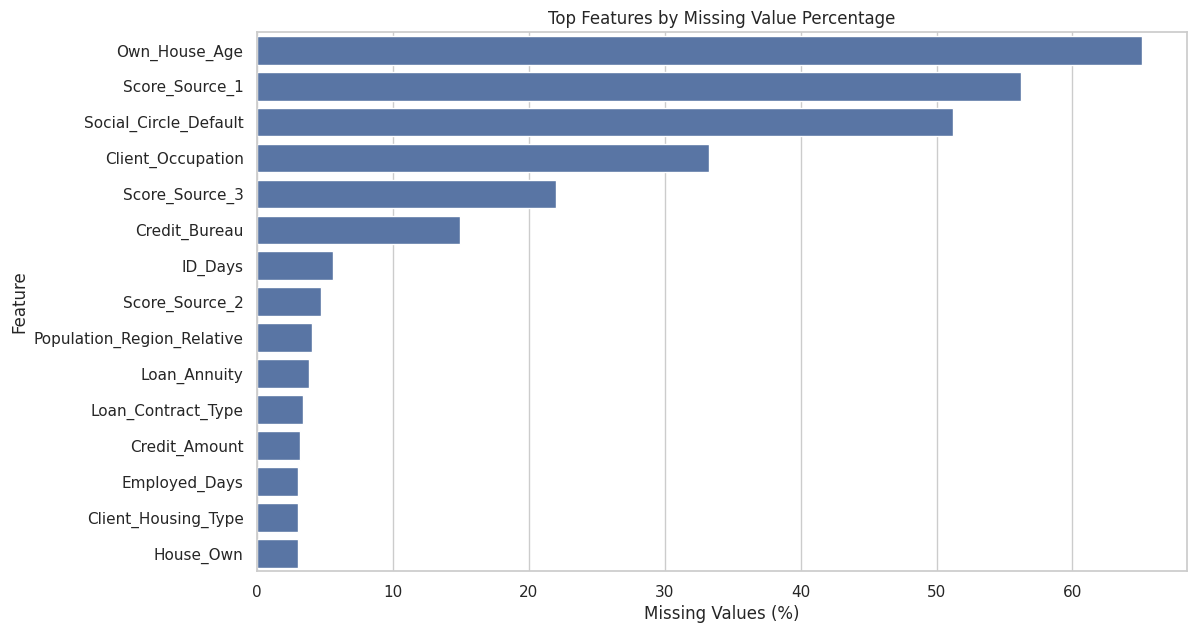

In [35]:
plt.figure(figsize=(12, 7))

missing_plot = missing_summary.head(15)

sns.barplot(
    x=missing_plot["Missing_Percentage"],
    y=missing_plot.index
)

plt.xlabel("Missing Values (%)")
plt.ylabel("Feature")
plt.title("Top Features by Missing Value Percentage")
plt.show()

### Missing Value Strategy

Missing values will be handled differently depending on the semantic type of the
attribute.

For numerical attributes:
- Median imputation will be used initially because financial and duration variables
  may be skewed and the median is less sensitive to extreme observations.

For categorical attributes:
- Missing values will be replaced using the most frequent category or an explicit
  "Missing" category.

For selected important attributes, missingness indicators may also be created.

A missing value can itself contain information. For example, the absence of a score
from an external scoring source may not be random and could potentially be associated
with application or customer characteristics.

Therefore, missingness will be investigated rather than automatically discarded.

In [36]:
# Search for common special string values

special_values = ["XNA", "##", "NA", "N/A", "NULL", "null", ""]

special_value_summary = {}

for col in df_clean.select_dtypes(include="object").columns:
    counts = df_clean[col].isin(special_values).sum()

    if counts > 0:
        special_value_summary[col] = counts

special_value_summary = (
    pd.Series(special_value_summary)
    .sort_values(ascending=False)
)

display(special_value_summary)

,0
Type_Organization,1054
Accompany_Client,1


In [37]:
# Inspect unusually large values in duration-related columns

duration_columns = [
    "Age_Days",
    "Employed_Days",
    "Registration_Days",
    "ID_Days"
]

# Convert duration columns to numeric, coercing errors to NaN
for col in duration_columns:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

for col in duration_columns:
    print(f"\n--- {col} ---")
    print(df_clean[col].head(10).tolist())
    print("Minimum:", df_clean[col].min())
    print("Maximum:", df_clean[col].max())


--- Age_Days ---
[22827.0, 8378.0, 14367.0, 14666.0, 15066.0, 13850.0, 16183.0, 16219.0, 17585.0, 11558.0]
Minimum: 7689.0
Maximum: 25201.0

--- Employed_Days ---
[365243.0, 1525.0, 365243.0, 3974.0, 8223.0, 926.0, 7153.0, 2876.0, 1206.0, 1512.0]
Minimum: 9.0
Maximum: 365243.0

--- Registration_Days ---
[7688.0, 329.0, 2292.0, 7342.0, 1470.0, 7679.0, 4385.0, 1725.0, nan, 10128.0]
Minimum: 0.0
Maximum: 19152.0

--- ID_Days ---
[nan, 1056.0, 4431.0, 5285.0, 4699.0, 1731.0, 4012.0, 4968.0, 1130.0, 640.0]
Minimum: 0.0
Maximum: 6263.0


## Handling Sentinel Values

Some datasets use special numerical values to represent a condition such as
"not applicable" or "unknown".

A value such as `365243` in `Employed_Days` should therefore not automatically be
interpreted as approximately 1,000 years of employment.

Such sentinel values must be converted into missing values before numerical
transformations are performed.

This is an important data-cleaning step because otherwise derived variables such as
Employment Years or Employment-to-Age Ratio could become meaningless.

In [38]:
numeric_as_text = [
    "Client_Income",
    "Loan_Annuity",
    "Population_Region_Relative",
    "Age_Days",
    "Employed_Days",
    "Registration_Days",
    "ID_Days"
]

for col in numeric_as_text:
    df_clean[col] = pd.to_numeric(
        df_clean[col],
        errors="coerce"
    )

print("Numeric conversion completed.")

display(df_clean[numeric_as_text].dtypes)

Numeric conversion completed.


,0
Client_Income,float64
Loan_Annuity,float64
Population_Region_Relative,float64
Age_Days,float64
Employed_Days,float64
Registration_Days,float64
ID_Days,float64


In [39]:
# Handle known sentinel value in employment duration
if "Employed_Days" in df_clean.columns:
    df_clean.loc[
        df_clean["Employed_Days"] == 365243,
        "Employed_Days"
    ] = np.nan

print(
    "Remaining Employed_Days sentinel values:",
    (df_clean["Employed_Days"] == 365243).sum()
)

Remaining Employed_Days sentinel values: 0


In [40]:
# Convert day-based variables into more interpretable year-based variables

df_clean["Age_Years"] = (
    df_clean["Age_Days"].abs() / 365.25
)

df_clean["Employment_Years"] = (
    df_clean["Employed_Days"].abs() / 365.25
)

df_clean["Registration_Years"] = (
    df_clean["Registration_Days"].abs() / 365.25
)

df_clean["ID_Change_Years"] = (
    df_clean["ID_Days"].abs() / 365.25
)

duration_engineered = [
    "Age_Years",
    "Employment_Years",
    "Registration_Years",
    "ID_Change_Years"
]

display(df_clean[duration_engineered].describe().T)

,count,mean,std,min,25%,50%,75%,max
Age_Years,5821.0,43.979346,11.923679,21.051335,33.965777,43.143053,53.941136,68.996578
Employment_Years,4766.0,6.626929,6.547668,0.024641,2.086242,4.583162,8.782341,44.744695
Registration_Years,5831.0,13.693873,9.665599,0.000000,5.523614,12.279261,20.585900,52.435318
ID_Change_Years,5664.0,8.161514,4.141258,0.000000,4.681040,8.851472,11.734428,17.147159


### Why Transform Duration Variables?

The original attributes are expressed in days and may contain negative values because
of the dataset's representation of time intervals.

For interpretation and feature engineering, converting these attributes into years
makes them easier to understand.

For example:

- `Age_Days` → `Age_Years`
- `Employed_Days` → `Employment_Years`
- `Registration_Days` → `Registration_Years`
- `ID_Days` → `ID_Change_Years`

The original attributes can be retained initially so that different models can
determine whether the transformed representation provides additional value.

The final feature-selection stage can remove redundant representations if required.

# Phase 3 — Exploratory Data Analysis

# 3. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the characteristics of
the customer population and identify relationships that may help predict loan default.

The analysis will cover:

- Numerical feature distributions
- Categorical feature distributions
- Outliers
- Relationships between important financial variables
- Default rate across categorical groups
- Correlation between numerical variables
- Relationship between missingness and default

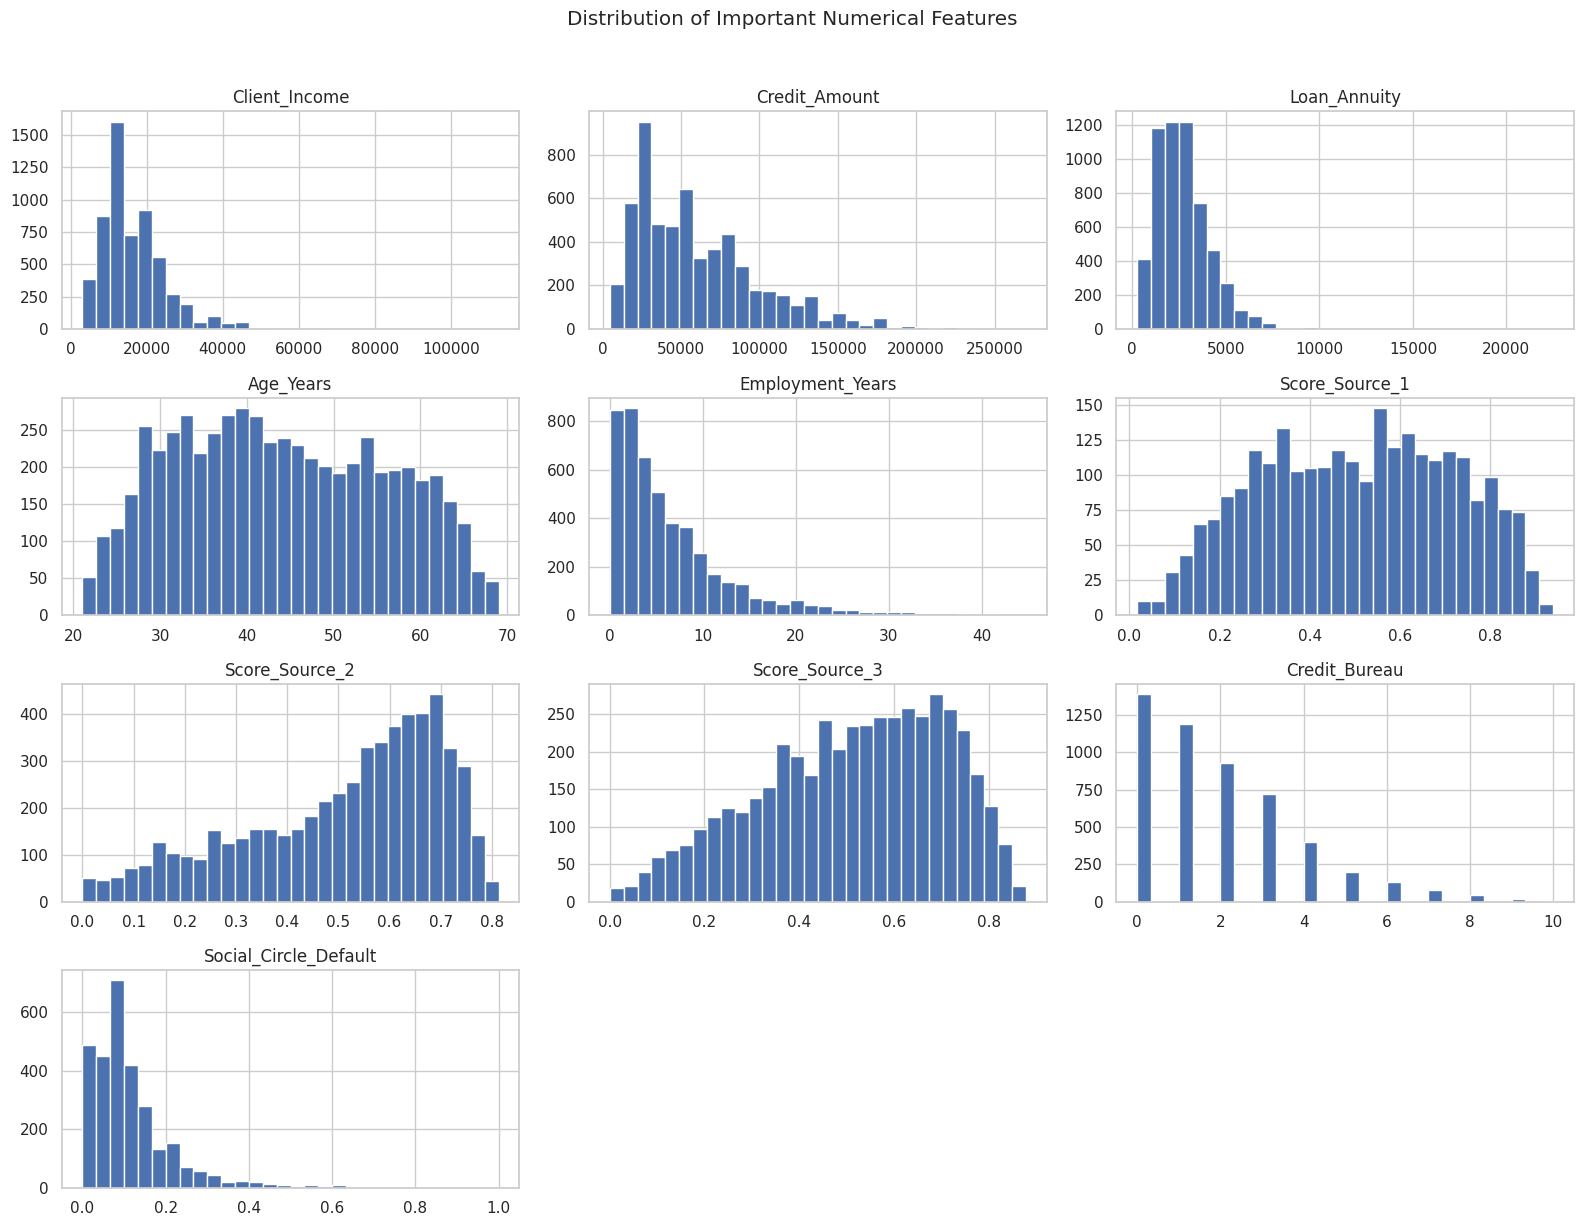

In [41]:
important_numeric = [
    "Client_Income",
    "Credit_Amount",
    "Loan_Annuity",
    "Age_Years",
    "Employment_Years",
    "Score_Source_1",
    "Score_Source_2",
    "Score_Source_3",
    "Credit_Bureau",
    "Social_Circle_Default"
]

available_numeric = [
    c for c in important_numeric
    if c in df_clean.columns
]

df_clean[available_numeric].hist(
    figsize=(16, 12),
    bins=30
)

plt.suptitle(
    "Distribution of Important Numerical Features",
    y=1.02
)

plt.tight_layout()
plt.show()

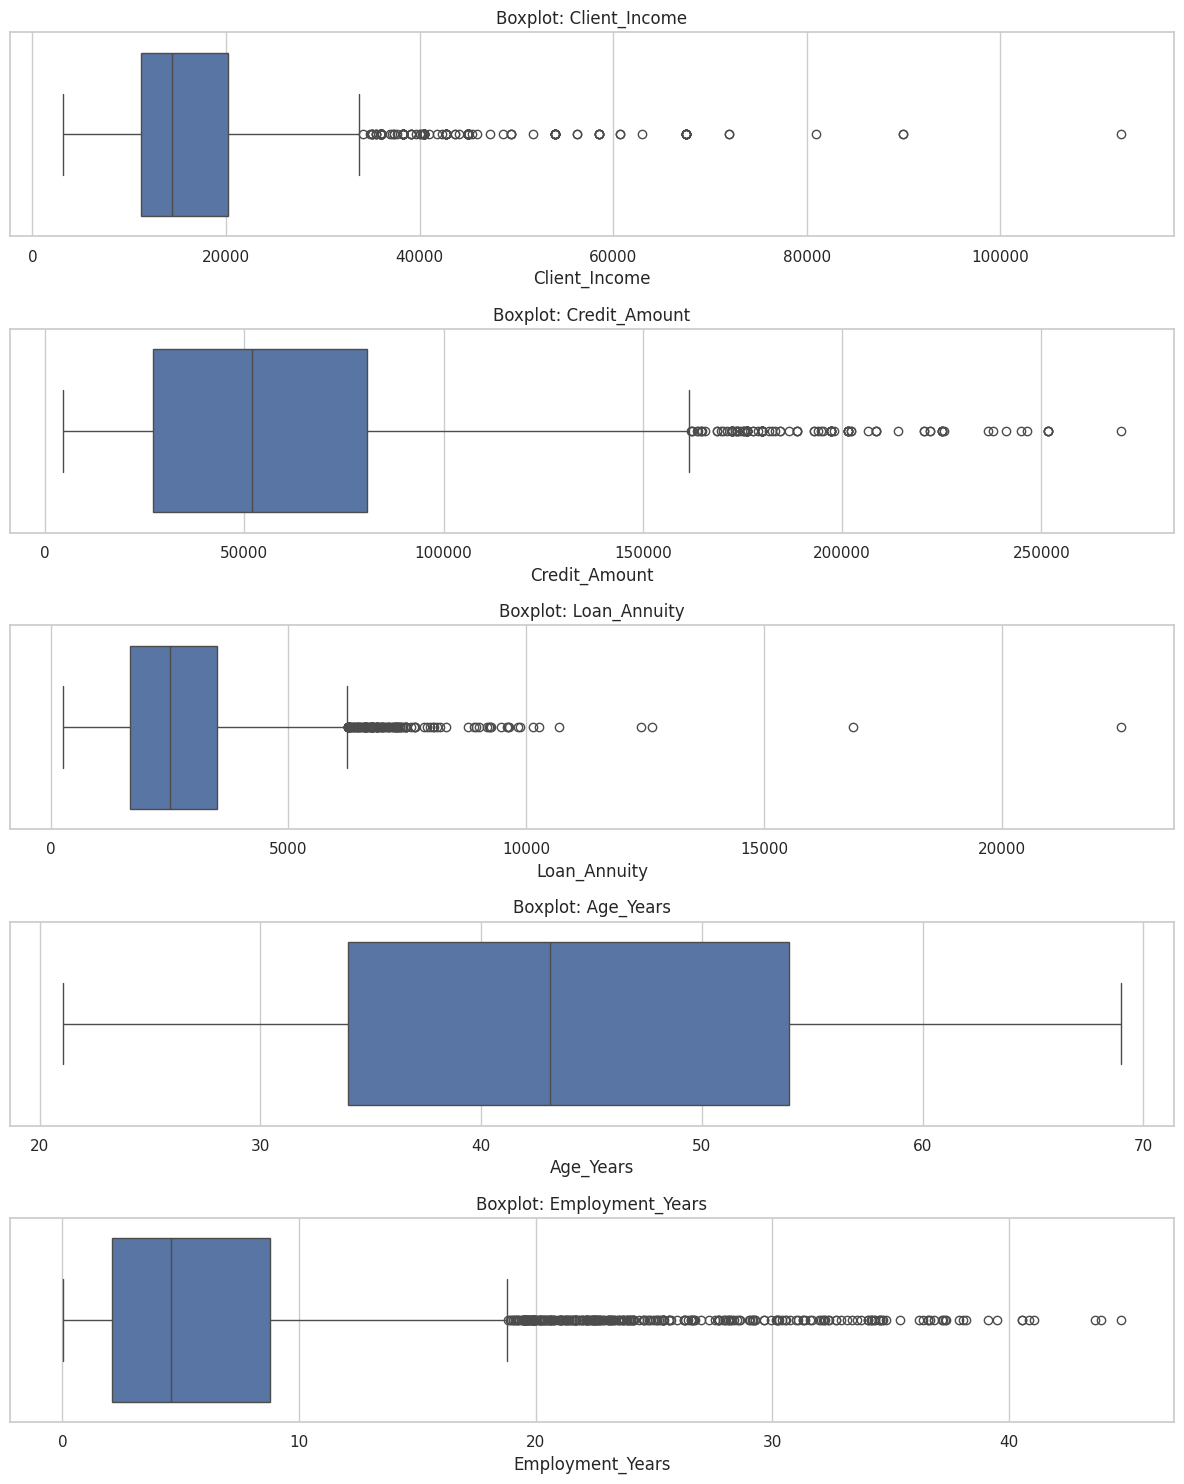

In [42]:
selected_boxplot_features = [
    "Client_Income",
    "Credit_Amount",
    "Loan_Annuity",
    "Age_Years",
    "Employment_Years"
]

fig, axes = plt.subplots(
    len(selected_boxplot_features),
    1,
    figsize=(12, 15)
)

for ax, col in zip(axes, selected_boxplot_features):
    sns.boxplot(
        x=df_clean[col],
        ax=ax
    )
    ax.set_title(f"Boxplot: {col}")

plt.tight_layout()
plt.show()

### Outlier Interpretation

Outliers will not automatically be removed.

In a loan-default prediction problem, extreme income, loan amount, or credit-related
values may represent genuine customers rather than data errors.

Therefore:

- Clearly invalid values will be corrected.
- Known sentinel values will be converted to missing values.
- Genuine extreme observations will generally be retained.
- Tree-based algorithms will be evaluated because they are relatively robust to
  monotonic transformations and extreme values.
- Log-transformed versions of strongly skewed monetary variables may be evaluated
  as engineered features.

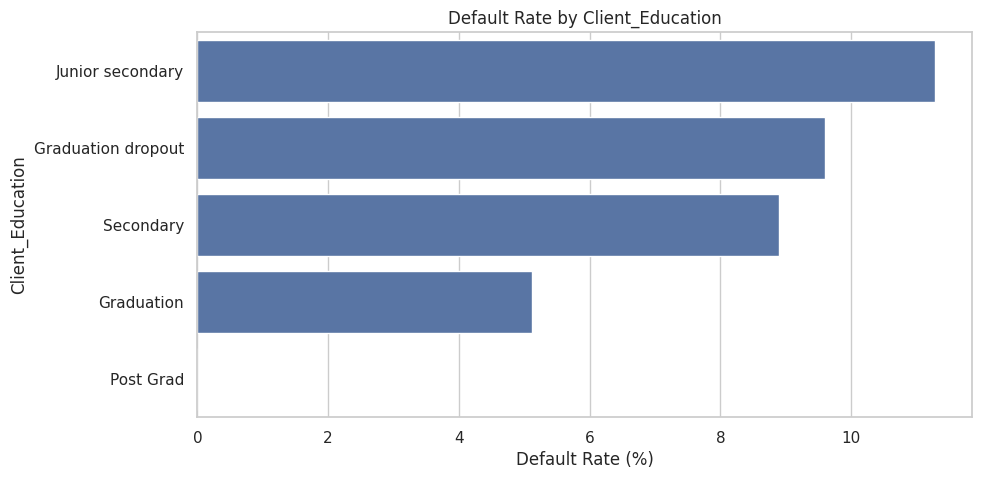

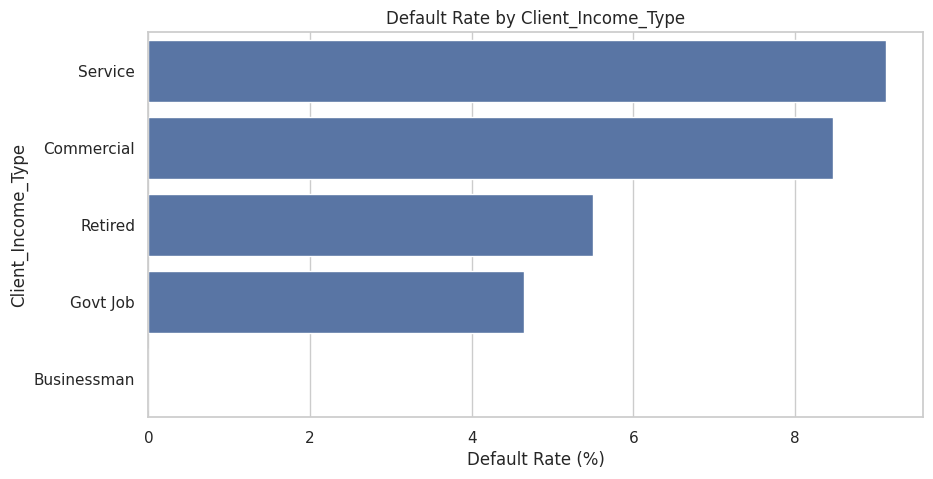

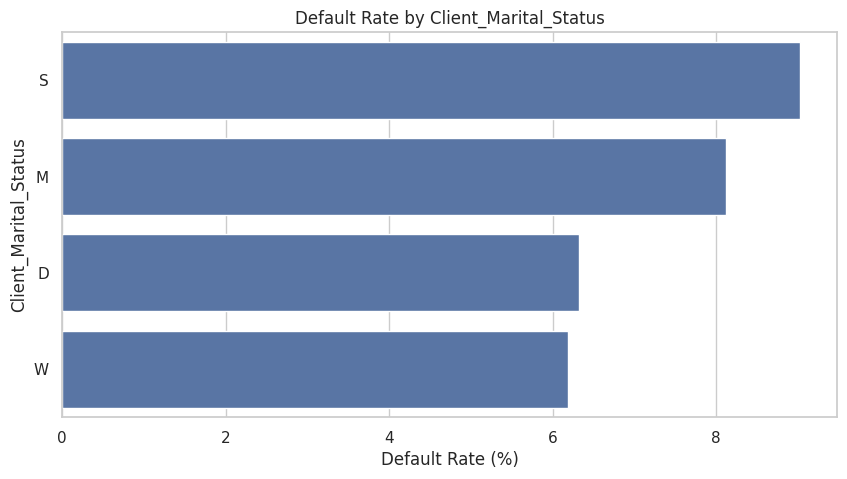

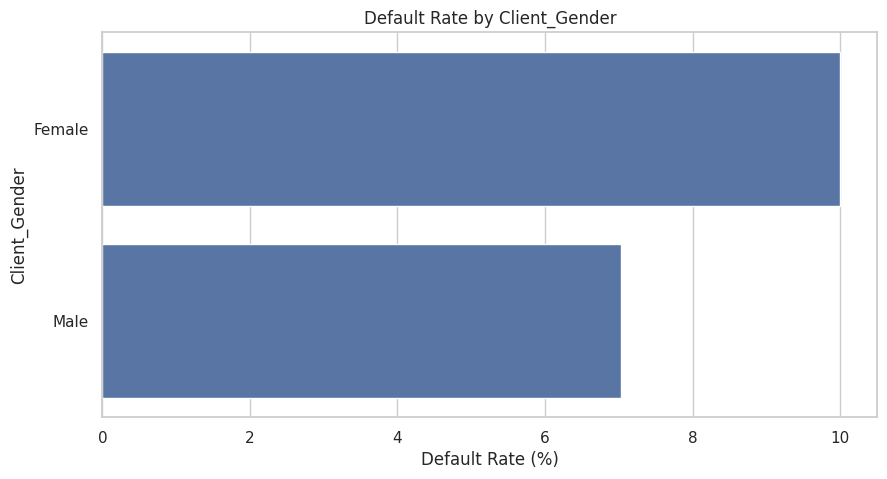

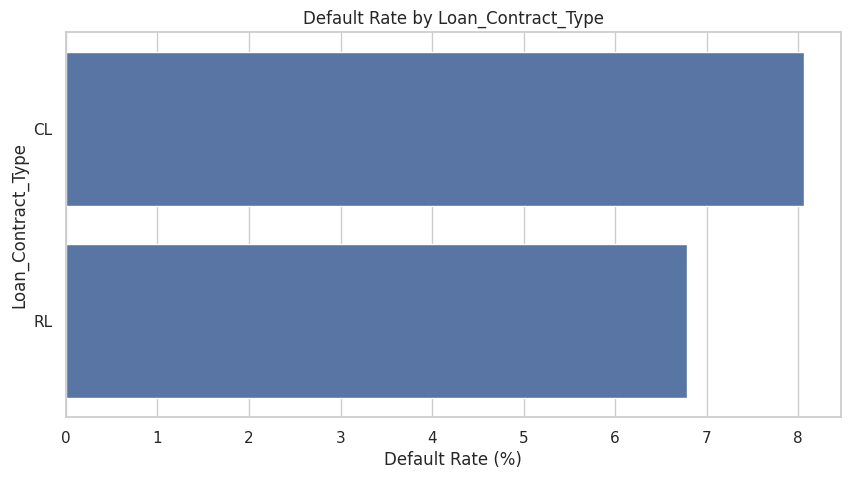

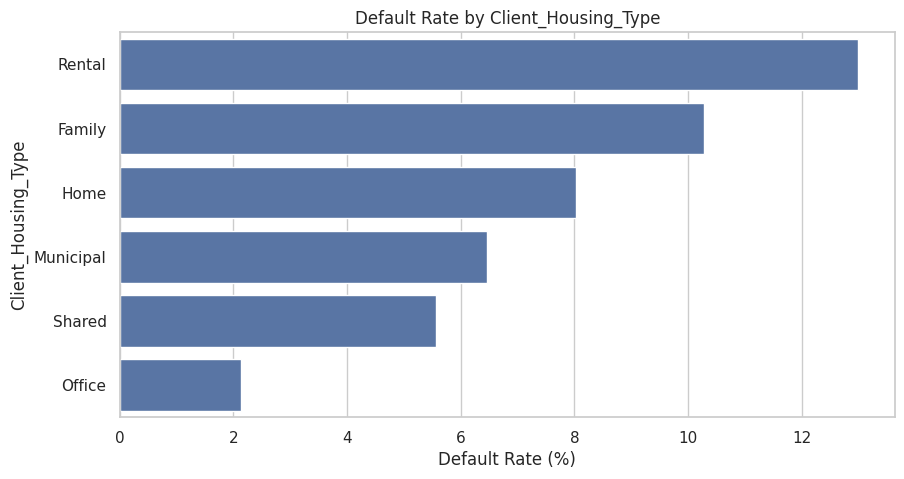

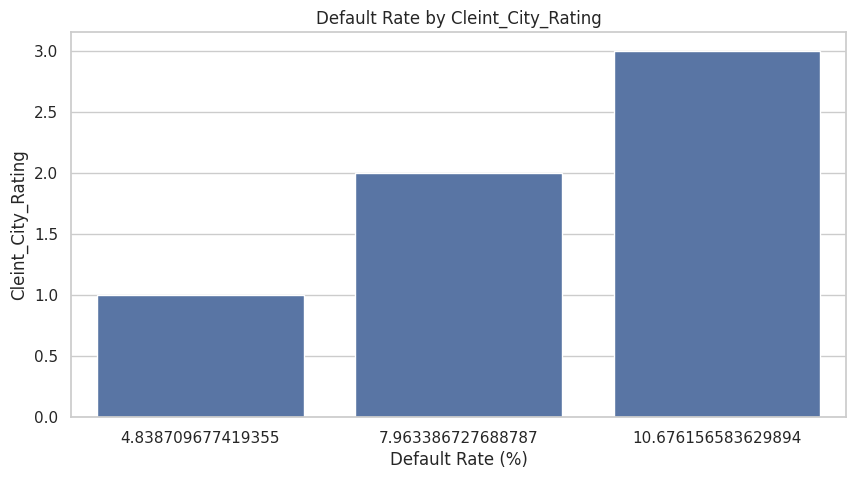

In [43]:
#Default Rate by Categorical Features
categorical_eda_features = [
    "Client_Education",
    "Client_Income_Type",
    "Client_Marital_Status",
    "Client_Gender",
    "Loan_Contract_Type",
    "Client_Housing_Type",
    "Cleint_City_Rating"
]

for col in categorical_eda_features:

    if col not in df_clean.columns:
        continue

    default_rate = (
        df_clean.groupby(col)["Default"]
        .mean()
        .sort_values(ascending=False)
        * 100
    )

    plt.figure(figsize=(10, 5))

    sns.barplot(
        x=default_rate.values,
        y=default_rate.index
    )

    plt.xlabel("Default Rate (%)")
    plt.ylabel(col)
    plt.title(f"Default Rate by {col}")

    plt.show()

# Phase 4 — Feature Engineering

# 4. Feature Engineering

Feature engineering converts raw attributes into representations that may better
capture the underlying financial and behavioral relationships associated with
loan default.

The following groups of features will be considered:

1. Financial ratios
2. Age and employment features
3. Family-related features
4. Credit-score aggregation
5. Missingness indicators
6. Application timing features
7. Log-transformed financial features

Feature engineering will be performed without using the target variable as an input.

This prevents direct target leakage.

In [44]:
# Safe division helper
def safe_divide(numerator, denominator):
    return numerator / denominator.replace(0, np.nan)

#Financial Features
# Ensure Credit_Amount is numeric before division
# It was identified as an object type in raw_dtype_summary and
# was not included in numeric_text_features for conversion earlier.
df_clean["Credit_Amount"] = pd.to_numeric(df_clean["Credit_Amount"], errors='coerce')

df_clean["Loan_to_Income_Ratio"] = safe_divide(
    df_clean["Credit_Amount"],
    df_clean["Client_Income"]
)

df_clean["Annuity_to_Income_Ratio"] = safe_divide(
    df_clean["Loan_Annuity"],
    df_clean["Client_Income"]
)

df_clean["Credit_per_Family_Member"] = safe_divide(
    df_clean["Credit_Amount"],
    df_clean["Client_Family_Members"]
)

df_clean["Children_to_Family_Ratio"] = safe_divide(
    df_clean["Child_Count"],
    df_clean["Client_Family_Members"]
)

In [45]:
score_columns = [
    "Score_Source_1",
    "Score_Source_2",
    "Score_Source_3"
]

# Ensure Score_Source_3 is numeric, as it was identified as an object type
df_clean["Score_Source_3"] = pd.to_numeric(df_clean["Score_Source_3"], errors='coerce')

available_score_columns = [
    c for c in score_columns
    if c in df_clean.columns
]

df_clean["Average_Credit_Score"] = (
    df_clean[available_score_columns].mean(axis=1)
)

df_clean["Min_Credit_Score"] = (
    df_clean[available_score_columns].min(axis=1)
)

df_clean["Max_Credit_Score"] = (
    df_clean[available_score_columns].max(axis=1)
)

df_clean["Credit_Score_Range"] = (
    df_clean[available_score_columns].max(axis=1)
    - df_clean[available_score_columns].min(axis=1)
)

df_clean["Available_Credit_Scores"] = (
    df_clean[available_score_columns].notna().sum(axis=1)
)

display(
    df_clean[
        available_score_columns
        + [
            "Average_Credit_Score",
            "Min_Credit_Score",
            "Max_Credit_Score",
            "Credit_Score_Range",
            "Available_Credit_Scores"
        ]
    ].head()
)

,Score_Source_1,Score_Source_2,Score_Source_3,Average_Credit_Score,Min_Credit_Score,Max_Credit_Score,Credit_Score_Range,Available_Credit_Scores
0,NaN,0.742129,NaN,0.742129,0.742129,0.742129,0.000000,1
1,NaN,0.218044,0.454321,0.336182,0.218044,0.454321,0.236277,2
2,0.801654,0.567663,0.633032,0.667450,0.567663,0.801654,0.233990,3
3,NaN,0.511677,0.713631,0.612654,0.511677,0.713631,0.201954,2
4,0.440522,0.582985,0.422370,0.481959,0.422370,0.582985,0.160616,3


In [46]:
missing_indicator_features = [
    "Score_Source_1",
    "Score_Source_3",
    "Client_Occupation",
    "Credit_Bureau",
    "Social_Circle_Default"
]

for col in missing_indicator_features:

    if col in df_clean.columns:
        df_clean[f"{col}_Missing"] = (
            df_clean[col].isna().astype(int)
        )

print("Missingness indicators created.")

Missingness indicators created.


In [47]:
# Cyclical representation of application hour

if "Application_Process_Hour" in df_clean.columns:

    df_clean["Application_Hour_Sin"] = np.sin(
        2 * np.pi * df_clean["Application_Process_Hour"] / 24
    )

    df_clean["Application_Hour_Cos"] = np.cos(
        2 * np.pi * df_clean["Application_Process_Hour"] / 24
    )

In [48]:
# Log transformation of strongly right-skewed positive monetary variables

for col in ["Client_Income", "Credit_Amount", "Loan_Annuity"]:

    if col in df_clean.columns:
        df_clean[f"{col}_Log"] = np.log1p(
            df_clean[col].clip(lower=0)
        )

## Feature Engineering Review

The engineered features represent several different hypotheses:

### Financial burden
`Loan_to_Income_Ratio` and `Annuity_to_Income_Ratio` measure the relative financial
burden of the requested loan.

### Household burden
`Credit_per_Family_Member` and `Children_to_Family_Ratio` provide normalized
representations of family-related financial pressure.

### Credit quality
The individual external scores are supplemented with aggregate measures such as
average, minimum, maximum and range.

### Data availability
Missingness indicators allow the model to distinguish between an actual low score
and an unavailable score.

### Time representation
Cyclical encoding represents application hour without incorrectly treating hour 23
and hour 0 as far apart.

### Distribution normalization
Log-transformed financial variables can reduce the influence of highly skewed
monetary distributions, particularly for linear models.

These features will subsequently be evaluated through correlation analysis, filter
methods and model-based importance.

# Phase 5 — Correlation Analysis

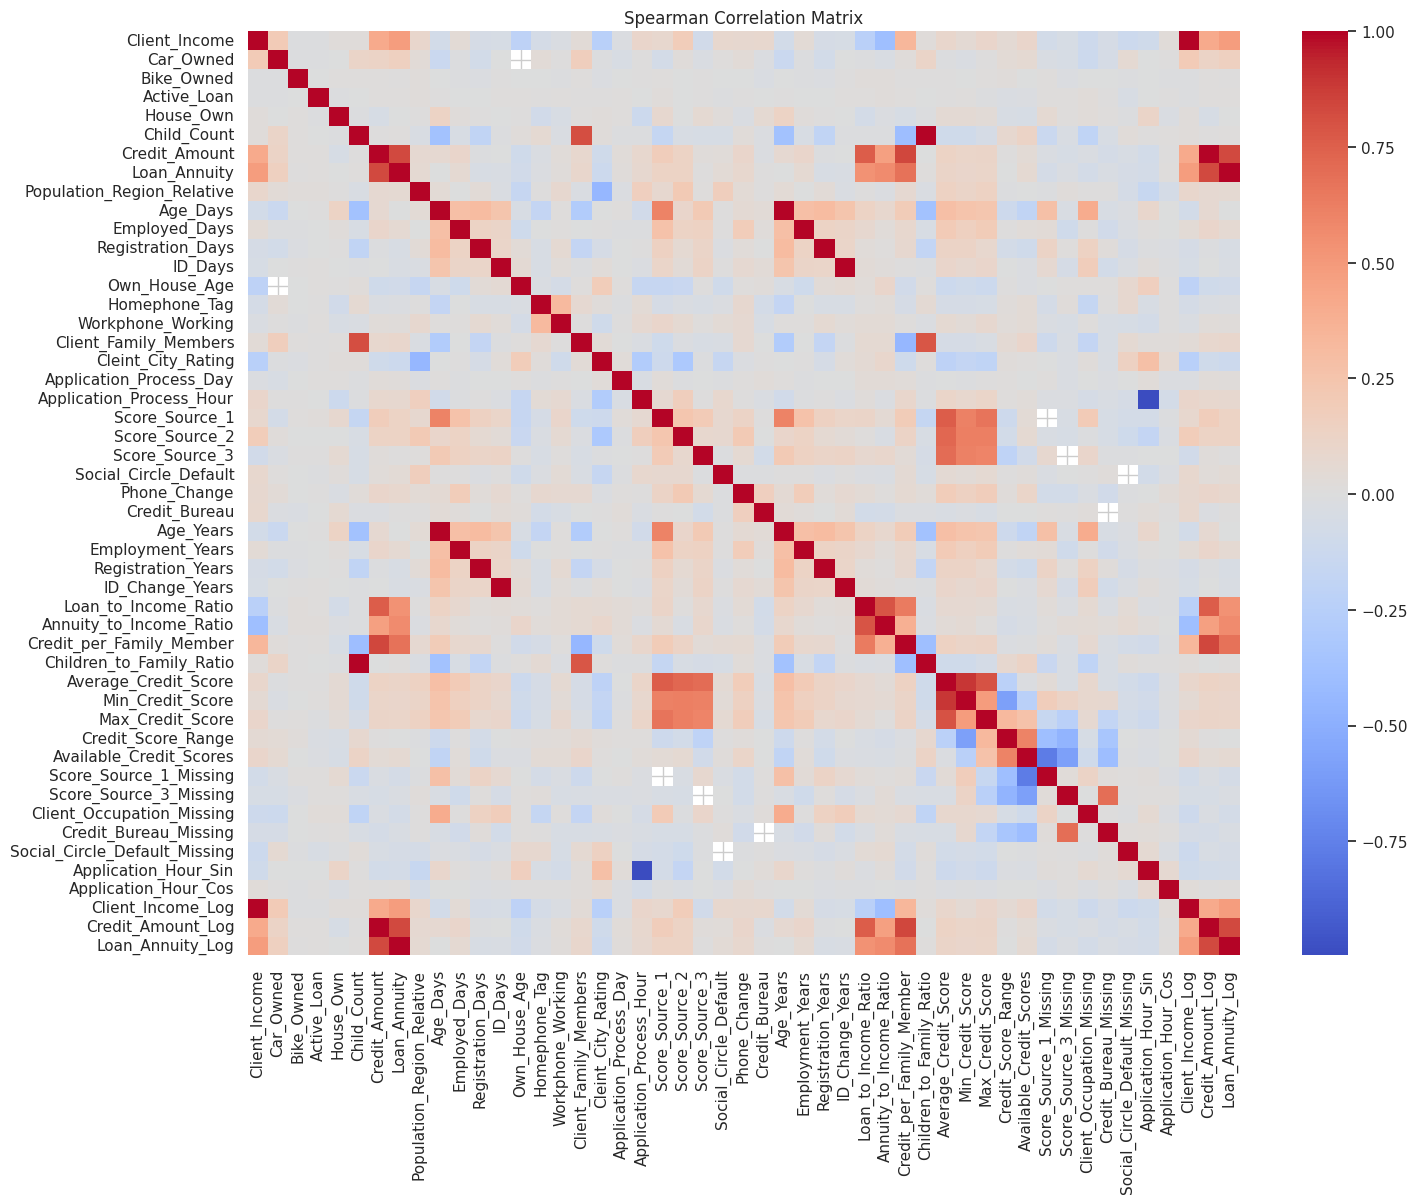

In [49]:
numeric_for_correlation = df_clean.select_dtypes(
    include=np.number
).copy()

# Exclude target and ID
numeric_for_correlation = numeric_for_correlation.drop(
    columns=[TARGET, ID_COLUMN],
    errors="ignore"
)

correlation_matrix = numeric_for_correlation.corr(
    method="spearman"
)

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Spearman Correlation Matrix")
plt.show()

In [50]:
corr_abs = correlation_matrix.abs()

upper_triangle = corr_abs.where(
    np.triu(
        np.ones(corr_abs.shape),
        k=1
    ).astype(bool)
)

high_corr_pairs = (
    upper_triangle
    .stack()
    .sort_values(ascending=False)
)

high_corr_pairs = high_corr_pairs[
    high_corr_pairs > 0.80
]

display(
    high_corr_pairs.head(20).to_frame(
        "Absolute_Correlation"
    )
)

,,Absolute_Correlation
Client_Income,Client_Income_Log,1.000000
ID_Days,ID_Change_Years,1.000000
Loan_Annuity,Loan_Annuity_Log,1.000000
Age_Days,Age_Years,1.000000
Employed_Days,Employment_Years,1.000000
Registration_Days,Registration_Years,1.000000
Credit_Amount,Credit_Amount_Log,1.000000
Application_Process_Hour,Application_Hour_Sin,0.996760
Child_Count,Children_to_Family_Ratio,0.994048
Average_Credit_Score,Min_Credit_Score,0.898029


## Correlation Analysis Interpretation

Correlation analysis is used to identify potentially redundant numerical attributes.

A high correlation does not automatically mean that one feature must be removed.

The impact depends on the model:

- Logistic Regression can be affected by multicollinearity.
- PCA can benefit from correlated features because PCA explicitly identifies directions
  of maximum variance.
- Tree-based models are generally less sensitive to multicollinearity.

Therefore, correlation analysis will be treated as a diagnostic and feature-selection
input rather than an automatic deletion rule.

# Phase 6 — Filter-Based Feature Selection



Feature selection is performed to identify attributes that have useful statistical
relationships with the target variable.

Two complementary filter methods will be used:

### 1. Chi-Square Test
Used primarily for categorical variables.

It tests whether the distribution of a categorical attribute is independent of
the default outcome.

### 2. Mutual Information
Used for numerical variables.

It measures the amount of information that a feature provides about the target and
can capture nonlinear relationships.

These methods are model-independent and therefore provide an initial statistical
view of feature relevance.

Importantly, final feature-selection decisions for model training should be based
only on the training data to avoid information leakage.

In [51]:
#Chi-Square

from scipy.stats import chi2_contingency

categorical_chi_results = []

categorical_features_available = [
    col for col in categorical_features
    if col in df_clean.columns
]

for col in categorical_features_available:

    contingency_table = pd.crosstab(
        df_clean[col].fillna("Missing"),
        df_clean[TARGET]
    )

    chi2, p_value, dof, expected = chi2_contingency(
        contingency_table
    )

    categorical_chi_results.append({
        "Feature": col,
        "Chi2": chi2,
        "P_Value": p_value,
        "Degrees_of_Freedom": dof
    })

chi_results_df = pd.DataFrame(
    categorical_chi_results
).sort_values("P_Value")

display(chi_results_df)

,Feature,Chi2,P_Value,Degrees_of_Freedom
15,Type_Organization,109.005773,0.000029,56
11,Client_Gender,16.010928,0.000334,2
17,Cleint_City_Rating,18.267694,0.000387,3
16,Client_Education,21.799400,0.000572,5
9,Client_Income_Type,21.735455,0.000588,5
14,Client_Occupation,36.963149,0.005299,18
6,Client_Permanent_Match_Tag,7.465666,0.006289,1
7,Client_Contact_Work_Tag,6.665330,0.009831,1
4,Homephone_Tag,6.332510,0.011854,1
0,Car_Owned,8.749133,0.012594,2


In [52]:
from sklearn.feature_selection import mutual_info_classif

mi_features = [
    col for col in continuous_numerical_features
    if col in df_clean.columns
]

mi_data = df_clean[mi_features].copy()

mi_data = mi_data.fillna(
    mi_data.median(numeric_only=True)
)

mi_scores = mutual_info_classif(
    mi_data,
    df_clean[TARGET],
    random_state=RANDOM_STATE
)

mi_results_df = pd.DataFrame({
    "Feature": mi_features,
    "Mutual_Information": mi_scores
}).sort_values(
    "Mutual_Information",
    ascending=False
)

display(mi_results_df)

,Feature,Mutual_Information
4,Score_Source_3,0.012940
0,Credit_Amount,0.010092
3,Score_Source_2,0.008510
5,Phone_Change,0.006287
2,Score_Source_1,0.001259
1,Own_House_Age,0.000000


In [53]:
print("Top categorical features according to Chi-Square:")
display(chi_results_df.head(10))

print("\nTop numerical features according to Mutual Information:")
display(mi_results_df.head(10))

Top categorical features according to Chi-Square:


,Feature,Chi2,P_Value,Degrees_of_Freedom
15,Type_Organization,109.005773,0.000029,56
11,Client_Gender,16.010928,0.000334,2
17,Cleint_City_Rating,18.267694,0.000387,3
16,Client_Education,21.799400,0.000572,5
9,Client_Income_Type,21.735455,0.000588,5
14,Client_Occupation,36.963149,0.005299,18
6,Client_Permanent_Match_Tag,7.465666,0.006289,1
7,Client_Contact_Work_Tag,6.665330,0.009831,1
4,Homephone_Tag,6.332510,0.011854,1
0,Car_Owned,8.749133,0.012594,2



Top numerical features according to Mutual Information:


,Feature,Mutual_Information
4,Score_Source_3,0.012940
0,Credit_Amount,0.010092
3,Score_Source_2,0.008510
5,Phone_Change,0.006287
2,Score_Source_1,0.001259
1,Own_House_Age,0.000000


## Feature Selection Strategy

The filter methods provide statistical evidence about potentially useful features.

However, a feature will not be removed solely because it has a weak univariate
relationship with the target.

A feature can still be useful in combination with other attributes.

Therefore, the final modelling stage will compare:

1. Full engineered feature set
2. Reduced feature set where appropriate
3. Model-based feature importance

This provides a stronger feature-selection methodology than relying on a single
statistical test.

# Phase 7 — Train/Test Split

# 7. Train-Test Split

The dataset will now be divided into training and testing sets.

An 80:20 split will be used with stratification.

Stratification is particularly important because the target variable is imbalanced.
It ensures that the proportion of default and non-default observations remains
approximately consistent in both datasets.

The test set will remain untouched until final model evaluation.

All learned preprocessing operations, including imputation, scaling, encoding and PCA,
must be fitted using the training data only.

In [54]:
from sklearn.model_selection import train_test_split

X = df_clean.drop(
    columns=[TARGET, ID_COLUMN],
    errors="ignore"
)

y = df_clean[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training set: (4800, 60)
Testing set : (1200, 60)

Training target distribution:
Default
0    0.919583
1    0.080417
Name: proportion, dtype: float64

Testing target distribution:
Default
0    0.92
1    0.08
Name: proportion, dtype: float64


# Phase 8 — Preprocessing Architecture

# 8. Preprocessing Architecture

The project will use two parallel preprocessing branches.

## Branch A — Main / Non-PCA

```text
Raw Features
     ↓
Missing Value Imputation
     ↓
Categorical Encoding
     ↓
Numerical Scaling
     ↓
Model
```

## Branch B — PCA



```text
Raw Features
     ↓
Missing Value Imputation
     ↓
Categorical Encoding
     ↓
Numerical Scaling
     ↓
PCA
     ↓
Model
```

In [55]:
binary_categorical_features = [
    "Car_Owned",
    "Bike_Owned",
    "Active_Loan",
    "House_Own",
    "Homephone_Tag",
    "Workphone_Working",
    "Client_Permanent_Match_Tag",
    "Client_Contact_Work_Tag"
]

nominal_categorical_features = [
    "Accompany_Client",
    "Client_Income_Type",
    "Client_Marital_Status",
    "Client_Gender",
    "Loan_Contract_Type",
    "Client_Housing_Type",
    "Client_Occupation",
    "Type_Organization"
]

ordinal_categorical_features = [
    "Client_Education",
    "Cleint_City_Rating"
]

calendar_categorical_features = [
    "Application_Process_Day"
]

categorical_features_final = (
    binary_categorical_features
    + nominal_categorical_features
    + ordinal_categorical_features
    + calendar_categorical_features
)

numeric_features_final = [
    col for col in X_train.columns
    if col not in categorical_features_final
]

print("Categorical features:", len(categorical_features_final))
print("Numerical features  :", len(numeric_features_final))

Categorical features: 19
Numerical features  : 41


In [56]:
#Build Numeric and Categorical Transformers

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features_final
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features_final
        )
    ],
    remainder="drop"
)

**Main Non-PCA Branch**

In [57]:
# MAIN BRANCH: No PCA

preprocessor_no_pca = preprocessor

print("Main preprocessing branch created.")
print("PCA: NOT included")

Main preprocessing branch created.
PCA: NOT included


In [58]:
from sklearn.decomposition import PCA

# PCA branch
# n_components is initially set to retain 95% of the variance.
# We will inspect the actual number of components later.

pca = PCA(
    n_components=0.95,
    random_state=RANDOM_STATE
)

preprocessor_with_pca = Pipeline(
    steps=[
        (
            "preprocessing",
            preprocessor
        ),
        (
            "pca",
            pca
        )
    ]
)

print("PCA preprocessing branch created.")
print("PCA variance retention target: 95%")

PCA preprocessing branch created.
PCA variance retention target: 95%


In [59]:
print("""
PIPELINE ARCHITECTURE

MAIN BRANCH
------------
Imputation
    ↓
Encoding
    ↓
Standardization
    ↓
Model

PCA BRANCH
----------
Imputation
    ↓
Encoding
    ↓
Standardization
    ↓
PCA (95% variance)
    ↓
Model
""")


PIPELINE ARCHITECTURE

MAIN BRANCH
------------
Imputation
    ↓
Encoding
    ↓
Standardization
    ↓
Model

PCA BRANCH
----------
Imputation
    ↓
Encoding
    ↓
Standardization
    ↓
PCA (95% variance)
    ↓
Model



## Why Keep Both Branches?

Both approaches answer different questions.

### Non-PCA branch

The non-PCA branch answers:

> Can the models predict default effectively using the original and engineered
> feature representation?

Advantages:

- Better interpretability
- Easier feature importance analysis
- Easier business explanation
- Suitable for tree-based models
- Preserves original feature semantics

### PCA branch

The PCA branch answers:

> Can dimensionality reduction preserve predictive information while reducing
> the dimensionality of the feature space?

Advantages:

- Reduces dimensionality
- Removes linear redundancy
- Can improve computational efficiency
- Provides a useful comparison for linear models

### Final comparison

We will not assume beforehand that PCA is better.

Instead, both branches will be evaluated experimentally using the same:

- Training data
- Testing data
- Cross-validation strategy
- Evaluation metrics
- Candidate models

The final model will be selected based on predictive performance, stability,
interpretability and business suitability.

```text
PHASE 9 — BASELINE MODELS
│
├── Dummy Classifier
│
├── MAIN BRANCH — NO PCA
│   ├── Logistic Regression
│   ├── Decision Tree
│   ├── Random Forest
│   └── Gradient Boosting / HistGradientBoosting
│
└── PCA BRANCH
    ├── Logistic Regression + PCA
    ├── Decision Tree + PCA
    ├── Random Forest + PCA
    └── Gradient Boosting + PCA

                         TRAINING DATA
                              │
                              ▼
                     Common Preprocessing
                              │
                 ┌────────────┴────────────┐
                 │                         │
                 ▼                         ▼
             NO PCA                     WITH PCA
            MAIN BRANCH               EXPERIMENTAL
                 │                         │
       ┌─────────┼─────────┐       ┌───────┼───────┐
       ▼         ▼         ▼       ▼       ▼       ▼
    Logistic   Tree      Random  Logistic  Tree   Random
    Regression          Forest   Regression       Forest
       │         │         │       │       │       │
       └─────────┴─────────┘       └───────┴───────┘
                 │                         │
                 └────────────┬────────────┘
                              ▼
                     Model Comparison
                              │
                              ▼
                   Imbalance + Threshold
                              │
                              ▼
                     Final Evaluation
                              │
                              ▼
                   Explainability / Business

# Phase 8A — Final Data Audit Before Modelling

Before building machine learning models, a final audit is performed on the engineered dataset.

The purpose of this step is to ensure that:

- The target variable is not present among predictors
- The identifier column is excluded
- No object columns remain unexpectedly
- No infinite values are present
- Missing values are identified
- Constant features are identified
- Training and testing dimensions are correct
- The target distribution remains consistent after stratification
- No obvious target leakage is present

This audit acts as a final quality gate before model development.

In [60]:
# ============================================================
# PHASE 8A: FINAL DATA AUDIT
# ============================================================

print("=" * 70)
print("FINAL DATA AUDIT")
print("=" * 70)

# ------------------------------------------------------------
# 1. Target leakage check
# ------------------------------------------------------------

print("\n1. TARGET LEAKAGE CHECK")
print("-" * 50)

target_in_features = TARGET in X.columns

print("Target present in feature matrix:", target_in_features)

assert TARGET not in X.columns, (
    "ERROR: Target variable is present in X."
)

print("Target leakage check: PASSED")


# ------------------------------------------------------------
# 2. Identifier check
# ------------------------------------------------------------

print("\n2. IDENTIFIER CHECK")
print("-" * 50)

id_in_features = ID_COLUMN in X.columns

print("ID present in feature matrix:", id_in_features)

assert ID_COLUMN not in X.columns, (
    "ERROR: Identifier column is present in X."
)

print("Identifier check: PASSED")


# ------------------------------------------------------------
# 3. Data types
# ------------------------------------------------------------

print("\n3. DATA TYPE CHECK")
print("-" * 50)

object_columns = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Object columns remaining:")
print(object_columns)

print(
    "\nNumber of object columns:",
    len(object_columns)
)


# ------------------------------------------------------------
# 4. Infinite values
# ------------------------------------------------------------

print("\n4. INFINITE VALUE CHECK")
print("-" * 50)

numeric_X = X.select_dtypes(
    include=np.number
)

infinite_counts = np.isinf(
    numeric_X
).sum()

total_infinite = infinite_counts.sum()

print(
    "Total infinite values:",
    total_infinite
)

if total_infinite > 0:
    display(
        infinite_counts[
            infinite_counts > 0
        ].sort_values(
            ascending=False
        ).to_frame("Infinite_Count")
    )
else:
    print("No infinite values detected.")


# ------------------------------------------------------------
# 5. Missing values
# ------------------------------------------------------------

print("\n5. MISSING VALUE CHECK")
print("-" * 50)

missing_summary = (
    X.isnull()
     .sum()
     .sort_values(
         ascending=False
     )
)

missing_summary = (
    missing_summary[
        missing_summary > 0
    ]
    .to_frame("Missing_Count")
)

if len(missing_summary) > 0:
    missing_summary["Missing_Percentage"] = (
        missing_summary["Missing_Count"]
        / len(X)
        * 100
    )

    display(
        missing_summary
    )
else:
    print("No missing values detected.")


# ------------------------------------------------------------
# 6. Constant features
# ------------------------------------------------------------

print("\n6. CONSTANT FEATURE CHECK")
print("-" * 50)

constant_features = [
    col
    for col in X.columns
    if X[col].nunique(
        dropna=False
    ) <= 1
]

print(
    "Number of constant features:",
    len(constant_features)
)

if constant_features:
    print("Constant features:")
    print(constant_features)
else:
    print("No constant features detected.")


# ------------------------------------------------------------
# 7. Feature count
# ------------------------------------------------------------

print("\n7. FEATURE COUNT")
print("-" * 50)

print(
    "Total predictor columns:",
    X.shape[1]
)

print(
    "Training rows:",
    X_train.shape[0]
)

print(
    "Testing rows:",
    X_test.shape[0]
)


# ------------------------------------------------------------
# 8. Train/test shape
# ------------------------------------------------------------

print("\n8. TRAIN / TEST SHAPES")
print("-" * 50)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


# ------------------------------------------------------------
# 9. Class distribution
# ------------------------------------------------------------

print("\n9. CLASS DISTRIBUTION")
print("-" * 50)

audit_class_distribution = pd.DataFrame({
    "Train_Count": y_train.value_counts(),
    "Train_Percentage":
        y_train.value_counts(
            normalize=True
        ) * 100,

    "Test_Count": y_test.value_counts(),
    "Test_Percentage":
        y_test.value_counts(
            normalize=True
        ) * 100
}).sort_index()

display(
    audit_class_distribution
)


# ------------------------------------------------------------
# 10. Final audit summary
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL AUDIT SUMMARY")
print("=" * 70)

print(
    "Target leakage       : PASSED"
)

print(
    "Identifier exclusion : PASSED"
)

print(
    "Infinite values      :",
    "PASSED" if total_infinite == 0 else "REVIEW REQUIRED"
)

print(
    "Constant features    :",
    "PASSED" if len(constant_features) == 0
    else "REVIEW REQUIRED"
)

print(
    "Feature count        :",
    X.shape[1]
)

print(
    "Training observations:",
    X_train.shape[0]
)

print(
    "Testing observations :",
    X_test.shape[0]
)

FINAL DATA AUDIT

1. TARGET LEAKAGE CHECK
--------------------------------------------------
Target present in feature matrix: False
Target leakage check: PASSED

2. IDENTIFIER CHECK
--------------------------------------------------
ID present in feature matrix: False
Identifier check: PASSED

3. DATA TYPE CHECK
--------------------------------------------------
Object columns remaining:
['Accompany_Client', 'Client_Income_Type', 'Client_Education', 'Client_Marital_Status', 'Client_Gender', 'Loan_Contract_Type', 'Client_Housing_Type', 'Client_Occupation', 'Client_Permanent_Match_Tag', 'Client_Contact_Work_Tag', 'Type_Organization']

Number of object columns: 11

4. INFINITE VALUE CHECK
--------------------------------------------------
Total infinite values: 0
No infinite values detected.

5. MISSING VALUE CHECK
--------------------------------------------------


,Missing_Count,Missing_Percentage
Own_House_Age,3909,65.150000
Score_Source_1,3372,56.200000
Social_Circle_Default,3071,51.183333
Client_Occupation,1995,33.250000
Score_Source_3,1322,22.033333
Employment_Years,1234,20.566667
Employed_Days,1234,20.566667
Credit_Bureau,899,14.983333
Annuity_to_Income_Ratio,402,6.700000
Loan_to_Income_Ratio,361,6.016667



6. CONSTANT FEATURE CHECK
--------------------------------------------------
Number of constant features: 0
No constant features detected.

7. FEATURE COUNT
--------------------------------------------------
Total predictor columns: 60
Training rows: 4800
Testing rows: 1200

8. TRAIN / TEST SHAPES
--------------------------------------------------
X_train: (4800, 60)
X_test : (1200, 60)
y_train: (4800,)
y_test : (1200,)

9. CLASS DISTRIBUTION
--------------------------------------------------


,Train_Count,Train_Percentage,Test_Count,Test_Percentage
Default,,,,
0,4414,91.958333,1104,92.0
1,386,8.041667,96,8.0



FINAL AUDIT SUMMARY
Target leakage       : PASSED
Identifier exclusion : PASSED
Infinite values      : PASSED
Constant features    : PASSED
Feature count        : 60
Training observations: 4800
Testing observations : 1200


### Interpretation

The final audit confirms that the dataset is ready for supervised machine learning, subject to review of any issues reported above.

The test set remains untouched for model selection and will only be used during final evaluation.

The class distribution is also preserved through stratified sampling, which is important because default cases represent a minority of observations.

# PHASE 9 — Baseline Model


A Dummy Classifier is used as the baseline model.

The baseline uses the `most_frequent` strategy, meaning that it always predicts the majority class.

The purpose is not to build a useful prediction system, but to establish a minimum benchmark.

A machine learning model should provide meaningful improvement over this baseline, particularly in identifying the minority default class.

Because the target is imbalanced, accuracy alone is not sufficient.

The main evaluation metrics will therefore include:

- Precision
- Recall
- F1-score
- ROC-AUC
- PR-AUC

In [61]:
# ============================================================
# PHASE 9: BASELINE MODEL
# ============================================================

baseline_model = DummyClassifier(
    strategy="most_frequent"
)

baseline_model.fit(
    X_train,
    y_train
)

baseline_predictions = baseline_model.predict(
    X_test
)

baseline_probabilities = baseline_model.predict_proba(
    X_test
)[:, 1]

baseline_metrics = pd.DataFrame([{
    "Model": "Dummy Classifier",
    "Accuracy": accuracy_score(
        y_test,
        baseline_predictions
    ),
    "Precision": precision_score(
        y_test,
        baseline_predictions,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        baseline_predictions,
        zero_division=0
    ),
    "F1": f1_score(
        y_test,
        baseline_predictions,
        zero_division=0
    ),
    "ROC_AUC": roc_auc_score(
        y_test,
        baseline_probabilities
    ),
    "PR_AUC": average_precision_score(
        y_test,
        baseline_probabilities
    )
}])

display(baseline_metrics)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Dummy Classifier,0.92,0.0,0.0,0.0,0.5,0.08


### Baseline Interpretation

The Dummy Classifier provides the minimum performance benchmark.

Since the model always predicts the majority class, its recall for the default class is expected to be very low or zero.

The subsequent machine learning models should demonstrate whether they can identify default cases substantially better than this naive strategy.

## Phase 10 — Candidate Models: No PCA

The main modelling branch uses the original and engineered feature representation without PCA.

Six classification algorithms are compared:

1. Logistic Regression
2. L1-Regularized Logistic Regression
3. Decision Tree
4. Random Forest
5. Extra Trees
6. XGBoost

These models represent different modelling approaches:

* Logistic Regression provides an interpretable linear baseline.
* L1-Regularized Logistic Regression performs classification while encouraging sparse coefficients.
* Decision Tree captures nonlinear decision rules.
* Random Forest combines multiple decision trees using bagging.
* Extra Trees introduces additional randomization into tree construction.
* XGBoost is a gradient-boosting algorithm designed for strong performance on structured/tabular data.

The No-PCA branch is the main modelling branch because it preserves the original feature representation and therefore provides better interpretability for business and credit-risk analysis.

The models will initially be compared using the same preprocessing pipeline and stratified cross-validation.


In [62]:
# ============================================================
# PHASE 10: NO-PCA MODEL DEFINITIONS
# ============================================================

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier
)

from xgboost import XGBClassifier


models_no_pca = {

    # --------------------------------------------------------
    # 1. Logistic Regression
    # --------------------------------------------------------
    "Logistic Regression":
        LogisticRegression(
            max_iter=2000,
            random_state=RANDOM_STATE
        ),

    # --------------------------------------------------------
    # 2. L1-Regularized Logistic Regression
    # --------------------------------------------------------
    "L1 Logistic Regression":
        LogisticRegression(
            penalty="l1",
            solver="liblinear",
            max_iter=2000,
            random_state=RANDOM_STATE
        ),

    # --------------------------------------------------------
    # 3. Decision Tree
    # --------------------------------------------------------
    "Decision Tree":
        DecisionTreeClassifier(
            random_state=RANDOM_STATE
        ),

    # --------------------------------------------------------
    # 4. Random Forest
    # --------------------------------------------------------
    "Random Forest":
        RandomForestClassifier(
            n_estimators=300,
            n_jobs=-1,
            random_state=RANDOM_STATE
        ),

    # --------------------------------------------------------
    # 5. Extra Trees
    # --------------------------------------------------------
    "Extra Trees":
        ExtraTreesClassifier(
            n_estimators=300,
            n_jobs=-1,
            random_state=RANDOM_STATE
        ),

    # --------------------------------------------------------
    # 6. XGBoost
    # --------------------------------------------------------
    "XGBoost":
        XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
}


print("Candidate No-PCA models:")
print()

for model_name in models_no_pca:
    print(" -", model_name)

Candidate No-PCA models:

 - Logistic Regression
 - L1 Logistic Regression
 - Decision Tree
 - Random Forest
 - Extra Trees
 - XGBoost


In [63]:
# ============================================================
# PHASE 10: CREATE NO-PCA MODEL PIPELINES
# ============================================================

pipelines_no_pca = {}

for model_name, model in models_no_pca.items():

    pipelines_no_pca[model_name] = Pipeline(
        steps=[
            (
                "preprocessing",
                preprocessor_no_pca
            ),
            (
                "model",
                model
            )
        ]
    )


print("No-PCA pipelines created:")
print()

for model_name in pipelines_no_pca:
    print(" -", model_name)

No-PCA pipelines created:

 - Logistic Regression
 - L1 Logistic Regression
 - Decision Tree
 - Random Forest
 - Extra Trees
 - XGBoost


# PHASE 11 — Multiple Models: PCA

## Phase 11 — PCA Model Experiment

A second modelling branch is created using Principal Component Analysis (PCA).

The PCA pipeline first performs the existing preprocessing and standardization, followed by PCA retaining approximately 95% of the variance.

PCA is evaluated primarily with Logistic Regression models because dimensionality reduction can be particularly useful for linear models when features are correlated or when the transformed feature space is high-dimensional.

Two models are evaluated:

1. Logistic Regression + PCA
2. L1-Regularized Logistic Regression + PCA

Tree-based models are not included in the main PCA comparison because PCA transforms the original variables into artificial components, which reduces feature interpretability and is generally less useful for tree-based models.

The PCA branch is therefore treated as an experimental comparison against the main No-PCA branch.


In [64]:
# ============================================================
# PHASE 11: PCA MODEL DEFINITIONS
# ============================================================

models_pca = {

    # --------------------------------------------------------
    # 1. Logistic Regression + PCA
    # --------------------------------------------------------
    "Logistic Regression + PCA":
        LogisticRegression(
            max_iter=2000,
            random_state=RANDOM_STATE
        ),

    # --------------------------------------------------------
    # 2. L1 Logistic Regression + PCA
    # --------------------------------------------------------
    "L1 Logistic Regression + PCA":
        LogisticRegression(
            penalty="l1",
            solver="liblinear",
            max_iter=2000,
            random_state=RANDOM_STATE
        )
}


print("Candidate PCA models:")
print()

for model_name in models_pca:
    print(" -", model_name)

Candidate PCA models:

 - Logistic Regression + PCA
 - L1 Logistic Regression + PCA


In [65]:
# ============================================================
# PHASE 11: CREATE PCA MODEL PIPELINES
# ============================================================

pipelines_pca = {}

for model_name, model in models_pca.items():

    pipelines_pca[model_name] = Pipeline(
        steps=[
            (
                "preprocessing",
                preprocessor_with_pca
            ),
            (
                "model",
                model
            )
        ]
    )


print("PCA pipelines created:")
print()

for model_name in pipelines_pca:
    print(" -", model_name)

PCA pipelines created:

 - Logistic Regression + PCA
 - L1 Logistic Regression + PCA


# PHASE 12 — Cross-Validation

## Phase 12 — Stratified Cross-Validation

The candidate models are now evaluated using 5-fold Stratified Cross-Validation on the training dataset.

Stratification ensures that the proportion of default and non-default observations is approximately preserved across folds.

The test set is not used during this stage.

Because loan default is an imbalanced classification problem, PR-AUC is used as the primary model comparison metric.

The following metrics are recorded:

* Accuracy
* Precision
* Recall
* F1-score
* ROC-AUC
* PR-AUC

PR-AUC is given greater importance because it focuses on the model's ability to identify the minority positive class while considering precision and recall.

The mean and standard deviation of PR-AUC across folds will also be examined to assess model stability.


In [66]:
# ============================================================
# PHASE 12: STRATIFIED CROSS-VALIDATION SETUP
# ============================================================

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate
)


cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)


scoring = {

    "accuracy": "accuracy",

    "precision": "precision",

    "recall": "recall",

    "f1": "f1",

    "roc_auc": "roc_auc",

    "pr_auc": "average_precision"
}


print("5-Fold Stratified Cross-Validation configured.")
print()
print("Number of folds :", cv.n_splits)
print("Primary metric  : PR-AUC")

5-Fold Stratified Cross-Validation configured.

Number of folds : 5
Primary metric  : PR-AUC


In [67]:
# ============================================================
# PHASE 12: CROSS-VALIDATE NO-PCA MODELS
# ============================================================

cv_results_no_pca = []


for model_name, pipeline in pipelines_no_pca.items():

    print(f"Running CV for: {model_name}")

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    cv_results_no_pca.append({

        "Model": model_name,

        "Branch": "No PCA",

        "Accuracy_Mean":
            scores["test_accuracy"].mean(),

        "Precision_Mean":
            scores["test_precision"].mean(),

        "Recall_Mean":
            scores["test_recall"].mean(),

        "F1_Mean":
            scores["test_f1"].mean(),

        "ROC_AUC_Mean":
            scores["test_roc_auc"].mean(),

        "PR_AUC_Mean":
            scores["test_pr_auc"].mean(),

        "PR_AUC_STD":
            scores["test_pr_auc"].std()
    })


cv_results_no_pca_df = (
    pd.DataFrame(cv_results_no_pca)
    .sort_values(
        "PR_AUC_Mean",
        ascending=False
    )
    .reset_index(drop=True)
)


print()
print("No-PCA Cross-Validation Results")
print("=" * 70)

display(cv_results_no_pca_df)

Running CV for: Logistic Regression
Running CV for: L1 Logistic Regression
Running CV for: Decision Tree
Running CV for: Random Forest
Running CV for: Extra Trees
Running CV for: XGBoost

No-PCA Cross-Validation Results


,Model,Branch,Accuracy_Mean,Precision_Mean,Recall_Mean,F1_Mean,ROC_AUC_Mean,PR_AUC_Mean,PR_AUC_STD
0,Random Forest,No PCA,0.919583,0.000000,0.000000,0.000000,0.673789,0.172358,0.018922
1,Logistic Regression,No PCA,0.918958,0.000000,0.000000,0.000000,0.680983,0.167623,0.022848
2,L1 Logistic Regression,No PCA,0.918750,0.000000,0.000000,0.000000,0.689727,0.166301,0.018609
3,XGBoost,No PCA,0.918125,0.133333,0.007759,0.014577,0.657808,0.164761,0.023542
4,Extra Trees,No PCA,0.919583,0.000000,0.000000,0.000000,0.651665,0.144056,0.014210
5,Decision Tree,No PCA,0.860833,0.163787,0.176257,0.169301,0.548481,0.095524,0.005354


In [68]:
# ============================================================
# PHASE 12: CROSS-VALIDATE PCA MODELS
# ============================================================

cv_results_pca = []


for model_name, pipeline in pipelines_pca.items():

    print(f"Running CV for: {model_name}")

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    cv_results_pca.append({

        "Model": model_name,

        "Branch": "PCA",

        "Accuracy_Mean":
            scores["test_accuracy"].mean(),

        "Precision_Mean":
            scores["test_precision"].mean(),

        "Recall_Mean":
            scores["test_recall"].mean(),

        "F1_Mean":
            scores["test_f1"].mean(),

        "ROC_AUC_Mean":
            scores["test_roc_auc"].mean(),

        "PR_AUC_Mean":
            scores["test_pr_auc"].mean(),

        "PR_AUC_STD":
            scores["test_pr_auc"].std()
    })


cv_results_pca_df = (
    pd.DataFrame(cv_results_pca)
    .sort_values(
        "PR_AUC_Mean",
        ascending=False
    )
    .reset_index(drop=True)
)


print()
print("PCA Cross-Validation Results")
print("=" * 70)

display(cv_results_pca_df)

Running CV for: Logistic Regression + PCA
Running CV for: L1 Logistic Regression + PCA

PCA Cross-Validation Results


,Model,Branch,Accuracy_Mean,Precision_Mean,Recall_Mean,F1_Mean,ROC_AUC_Mean,PR_AUC_Mean,PR_AUC_STD
0,Logistic Regression + PCA,PCA,0.919583,0.2,0.002597,0.005128,0.694375,0.176069,0.017072
1,L1 Logistic Regression + PCA,PCA,0.919792,0.2,0.002597,0.005128,0.695457,0.175231,0.016900


# PHASE 13 — Model Comparison

## Phase 13 — Model Comparison

The cross-validation results from the No-PCA and PCA branches are combined into a single comparison table.

The primary comparison metric is mean PR-AUC.

However, model selection will not be based on PR-AUC alone.

Recall, precision, F1-score, ROC-AUC and PR-AUC variability across folds will also be considered.

The purpose of this comparison is to identify a small number of promising candidate models for further investigation.

The untouched test set will not be used for this selection.


In [69]:
# ============================================================
# PHASE 13: COMPLETE MODEL COMPARISON
# ============================================================

all_cv_results = pd.concat(
    [
        cv_results_no_pca_df,
        cv_results_pca_df
    ],
    ignore_index=True
)


all_cv_results = (
    all_cv_results
    .sort_values(
        "PR_AUC_Mean",
        ascending=False
    )
    .reset_index(drop=True)
)


print("Complete Cross-Validation Model Comparison")
print("=" * 70)

display(all_cv_results)

Complete Cross-Validation Model Comparison


,Model,Branch,Accuracy_Mean,Precision_Mean,Recall_Mean,F1_Mean,ROC_AUC_Mean,PR_AUC_Mean,PR_AUC_STD
0,Logistic Regression + PCA,PCA,0.919583,0.200000,0.002597,0.005128,0.694375,0.176069,0.017072
1,L1 Logistic Regression + PCA,PCA,0.919792,0.200000,0.002597,0.005128,0.695457,0.175231,0.016900
2,Random Forest,No PCA,0.919583,0.000000,0.000000,0.000000,0.673789,0.172358,0.018922
3,Logistic Regression,No PCA,0.918958,0.000000,0.000000,0.000000,0.680983,0.167623,0.022848
4,L1 Logistic Regression,No PCA,0.918750,0.000000,0.000000,0.000000,0.689727,0.166301,0.018609
5,XGBoost,No PCA,0.918125,0.133333,0.007759,0.014577,0.657808,0.164761,0.023542
6,Extra Trees,No PCA,0.919583,0.000000,0.000000,0.000000,0.651665,0.144056,0.014210
7,Decision Tree,No PCA,0.860833,0.163787,0.176257,0.169301,0.548481,0.095524,0.005354


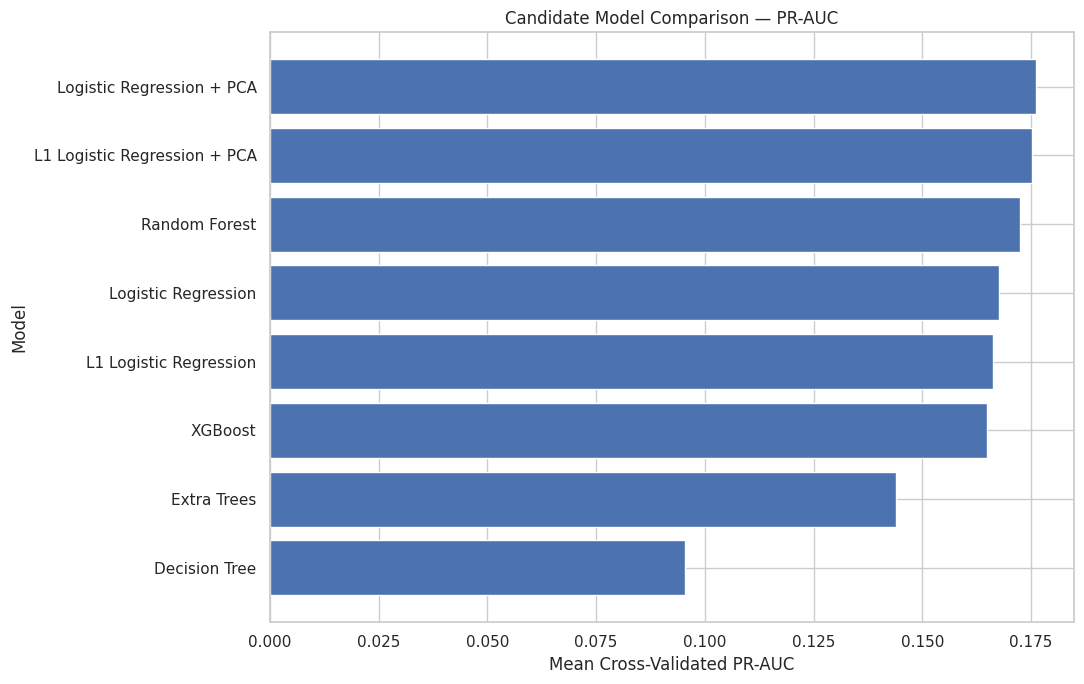

In [70]:
# ============================================================
# PHASE 13: MODEL COMPARISON — PR-AUC
# ============================================================

comparison_plot_df = (
    all_cv_results
    .sort_values(
        "PR_AUC_Mean",
        ascending=True
    )
)


plt.figure(
    figsize=(11, 7)
)


plt.barh(
    comparison_plot_df["Model"],
    comparison_plot_df["PR_AUC_Mean"]
)


plt.xlabel(
    "Mean Cross-Validated PR-AUC"
)

plt.ylabel(
    "Model"
)

plt.title(
    "Candidate Model Comparison — PR-AUC"
)

plt.tight_layout()

plt.show()

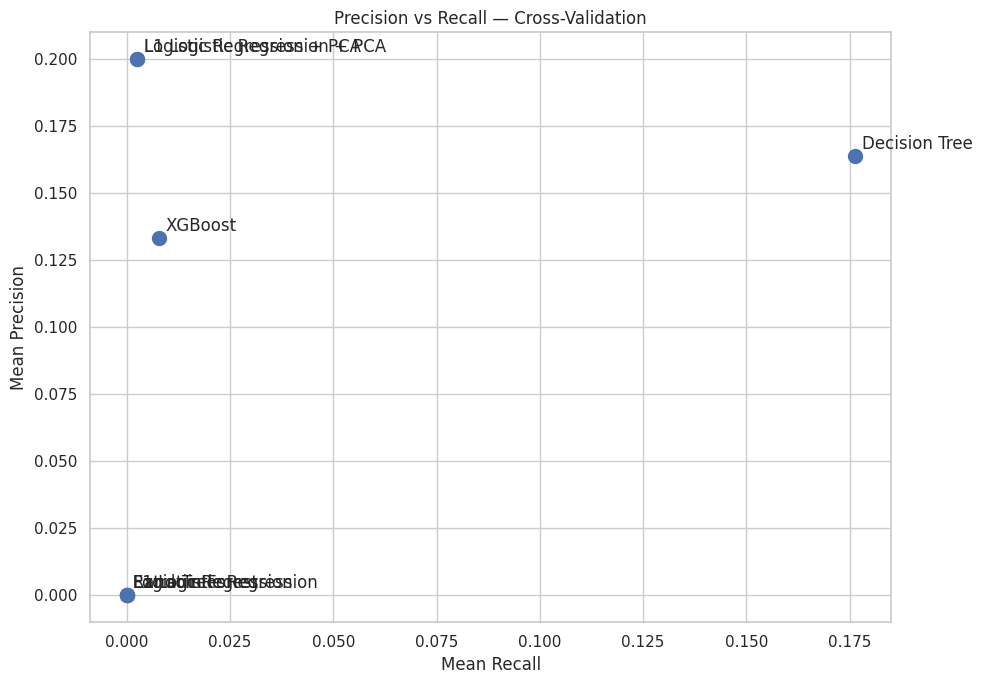

In [71]:
# ============================================================
# PHASE 13: PRECISION VS RECALL
# ============================================================

plt.figure(
    figsize=(10, 7)
)


plt.scatter(
    all_cv_results["Recall_Mean"],
    all_cv_results["Precision_Mean"],
    s=100
)


for _, row in all_cv_results.iterrows():

    plt.annotate(
        row["Model"],
        (
            row["Recall_Mean"],
            row["Precision_Mean"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )


plt.xlabel(
    "Mean Recall"
)

plt.ylabel(
    "Mean Precision"
)

plt.title(
    "Precision vs Recall — Cross-Validation"
)

plt.tight_layout()

plt.show()

In [72]:
# ============================================================
# PHASE 13: MODEL STABILITY ANALYSIS
# ============================================================

stability_results = (
    all_cv_results[
        [
            "Model",
            "Branch",
            "PR_AUC_Mean",
            "PR_AUC_STD",
            "Recall_Mean",
            "Precision_Mean",
            "F1_Mean"
        ]
    ]
    .sort_values(
        "PR_AUC_Mean",
        ascending=False
    )
    .reset_index(drop=True)
)


display(stability_results)

,Model,Branch,PR_AUC_Mean,PR_AUC_STD,Recall_Mean,Precision_Mean,F1_Mean
0,Logistic Regression + PCA,PCA,0.176069,0.017072,0.002597,0.200000,0.005128
1,L1 Logistic Regression + PCA,PCA,0.175231,0.016900,0.002597,0.200000,0.005128
2,Random Forest,No PCA,0.172358,0.018922,0.000000,0.000000,0.000000
3,Logistic Regression,No PCA,0.167623,0.022848,0.000000,0.000000,0.000000
4,L1 Logistic Regression,No PCA,0.166301,0.018609,0.000000,0.000000,0.000000
5,XGBoost,No PCA,0.164761,0.023542,0.007759,0.133333,0.014577
6,Extra Trees,No PCA,0.144056,0.014210,0.000000,0.000000,0.000000
7,Decision Tree,No PCA,0.095524,0.005354,0.176257,0.163787,0.169301


# PHASE 14 — Class Imbalance Handling

## Phase 14 — Class Imbalance Handling

The cross-validation results indicate a substantial class-imbalance challenge.

Most models achieve relatively high accuracy while producing extremely low recall for the default class. This indicates that the models tend to favor the majority non-default class.

Since identifying potential defaulters is an important objective of the problem, class imbalance will be addressed before final model selection.

Two approaches will be compared:

### Standard training

The model is trained using the original class distribution.

### Class-weighted training

The minority default class is assigned greater importance during model training.

The following models will be evaluated with class balancing:

* Logistic Regression
* L1 Logistic Regression
* Decision Tree
* Random Forest
* Extra Trees
* XGBoost

For XGBoost, the `scale_pos_weight` parameter will be calculated from the training data.

Five-fold stratified cross-validation will again be used, with PR-AUC as the primary metric.

The test set remains untouched.


In [73]:
# ============================================================
# PHASE 14: CALCULATE CLASS IMBALANCE
# ============================================================

class_counts = y_train.value_counts().sort_index()

negative_count = class_counts[0]
positive_count = class_counts[1]

scale_pos_weight = (
    negative_count / positive_count
)

print("Training class distribution")
print("=" * 50)

print(
    "Non-Default (0):",
    negative_count
)

print(
    "Default (1):",
    positive_count
)

print(
    "Default percentage:",
    round(
        positive_count / len(y_train) * 100,
        2
    ),
    "%"
)

print(
    "Scale Pos Weight:",
    round(
        scale_pos_weight,
        2
    )
)

Training class distribution
Non-Default (0): 4414
Default (1): 386
Default percentage: 8.04 %
Scale Pos Weight: 11.44


In [74]:
#Create balanced versions of ALL six models

# ============================================================
# PHASE 14: BALANCED MODEL DEFINITIONS
# ============================================================

balanced_models = {

    # --------------------------------------------------------
    # 1. Balanced Logistic Regression
    # --------------------------------------------------------
    "Logistic Regression Balanced":
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ),

    # --------------------------------------------------------
    # 2. Balanced L1 Logistic Regression
    # --------------------------------------------------------
    "L1 Logistic Regression Balanced":
        LogisticRegression(
            penalty="l1",
            solver="liblinear",
            class_weight="balanced",
            max_iter=2000,
            random_state=RANDOM_STATE
        ),

    # --------------------------------------------------------
    # 3. Balanced Decision Tree
    # --------------------------------------------------------
    "Decision Tree Balanced":
        DecisionTreeClassifier(
            class_weight="balanced",
            random_state=RANDOM_STATE
        ),

    # --------------------------------------------------------
    # 4. Balanced Random Forest
    # --------------------------------------------------------
    "Random Forest Balanced":
        RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            n_jobs=-1,
            random_state=RANDOM_STATE
        ),

    # --------------------------------------------------------
    # 5. Balanced Extra Trees
    # --------------------------------------------------------
    "Extra Trees Balanced":
        ExtraTreesClassifier(
            n_estimators=300,
            class_weight="balanced",
            n_jobs=-1,
            random_state=RANDOM_STATE
        ),

    # --------------------------------------------------------
    # 6. Balanced XGBoost
    # --------------------------------------------------------
    "XGBoost Balanced":
        XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
}


print("Balanced models created:")
print()

for model_name in balanced_models:
    print(" -", model_name)

Balanced models created:

 - Logistic Regression Balanced
 - L1 Logistic Regression Balanced
 - Decision Tree Balanced
 - Random Forest Balanced
 - Extra Trees Balanced
 - XGBoost Balanced


In [75]:
# ============================================================
# PHASE 14: BALANCED MODEL PIPELINES
# ============================================================

balanced_pipelines = {}


for model_name, model in balanced_models.items():

    balanced_pipelines[model_name] = Pipeline(
        steps=[
            (
                "preprocessing",
                preprocessor_no_pca
            ),
            (
                "model",
                model
            )
        ]
    )


print("Balanced pipelines created:")
print()

for model_name in balanced_pipelines:
    print(" -", model_name)

Balanced pipelines created:

 - Logistic Regression Balanced
 - L1 Logistic Regression Balanced
 - Decision Tree Balanced
 - Random Forest Balanced
 - Extra Trees Balanced
 - XGBoost Balanced


In [76]:
# ============================================================
# PHASE 14: CROSS-VALIDATE BALANCED MODELS
# ============================================================

balanced_cv_results = []


for model_name, pipeline in balanced_pipelines.items():

    print(
        f"Running CV for: {model_name}"
    )

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    balanced_cv_results.append({

        "Model": model_name,

        "Branch": "Balanced",

        "Accuracy_Mean":
            scores["test_accuracy"].mean(),

        "Precision_Mean":
            scores["test_precision"].mean(),

        "Recall_Mean":
            scores["test_recall"].mean(),

        "F1_Mean":
            scores["test_f1"].mean(),

        "ROC_AUC_Mean":
            scores["test_roc_auc"].mean(),

        "PR_AUC_Mean":
            scores["test_pr_auc"].mean(),

        "PR_AUC_STD":
            scores["test_pr_auc"].std()
    })


balanced_cv_df = (
    pd.DataFrame(
        balanced_cv_results
    )
    .sort_values(
        "PR_AUC_Mean",
        ascending=False
    )
    .reset_index(drop=True)
)


print()
print("Balanced Model Cross-Validation Results")
print("=" * 70)

display(balanced_cv_df)

Running CV for: Logistic Regression Balanced
Running CV for: L1 Logistic Regression Balanced
Running CV for: Decision Tree Balanced
Running CV for: Random Forest Balanced
Running CV for: Extra Trees Balanced
Running CV for: XGBoost Balanced

Balanced Model Cross-Validation Results


,Model,Branch,Accuracy_Mean,Precision_Mean,Recall_Mean,F1_Mean,ROC_AUC_Mean,PR_AUC_Mean,PR_AUC_STD
0,Random Forest Balanced,Balanced,0.919583,0.000000,0.000000,0.000000,0.677397,0.185864,0.014610
1,Logistic Regression Balanced,Balanced,0.675000,0.130951,0.538828,0.210647,0.672723,0.161081,0.023610
2,L1 Logistic Regression Balanced,Balanced,0.673750,0.131738,0.546620,0.212279,0.677542,0.160897,0.019826
3,XGBoost Balanced,Balanced,0.842292,0.171629,0.251349,0.203263,0.661778,0.159318,0.016252
4,Extra Trees Balanced,Balanced,0.919583,0.000000,0.000000,0.000000,0.653701,0.148768,0.003767
5,Decision Tree Balanced,Balanced,0.850625,0.120092,0.134665,0.126663,0.523947,0.085945,0.002520


In [77]:
# ============================================================
# PHASE 15: STANDARD VS BALANCED COMPARISON
# ============================================================

standard_results = (
    all_cv_results[
        [
            "Model",
            "Branch",
            "PR_AUC_Mean",
            "PR_AUC_STD",
            "Recall_Mean",
            "Precision_Mean",
            "F1_Mean"
        ]
    ]
    .copy()
)

balanced_results = (
    balanced_cv_df[
        [
            "Model",
            "Branch",
            "PR_AUC_Mean",
            "PR_AUC_STD",
            "Recall_Mean",
            "Precision_Mean",
            "F1_Mean"
        ]
    ]
    .copy()
)


imbalance_comparison = pd.concat(
    [
        standard_results,
        balanced_results
    ],
    ignore_index=True
)


imbalance_comparison = (
    imbalance_comparison
    .sort_values(
        "PR_AUC_Mean",
        ascending=False
    )
    .reset_index(drop=True)
)


display(
    imbalance_comparison
)

,Model,Branch,PR_AUC_Mean,PR_AUC_STD,Recall_Mean,Precision_Mean,F1_Mean
0,Random Forest Balanced,Balanced,0.185864,0.014610,0.000000,0.000000,0.000000
1,Logistic Regression + PCA,PCA,0.176069,0.017072,0.002597,0.200000,0.005128
2,L1 Logistic Regression + PCA,PCA,0.175231,0.016900,0.002597,0.200000,0.005128
3,Random Forest,No PCA,0.172358,0.018922,0.000000,0.000000,0.000000
4,Logistic Regression,No PCA,0.167623,0.022848,0.000000,0.000000,0.000000
5,L1 Logistic Regression,No PCA,0.166301,0.018609,0.000000,0.000000,0.000000
6,XGBoost,No PCA,0.164761,0.023542,0.007759,0.133333,0.014577
7,Logistic Regression Balanced,Balanced,0.161081,0.023610,0.538828,0.130951,0.210647
8,L1 Logistic Regression Balanced,Balanced,0.160897,0.019826,0.546620,0.131738,0.212279
9,XGBoost Balanced,Balanced,0.159318,0.016252,0.251349,0.171629,0.203263


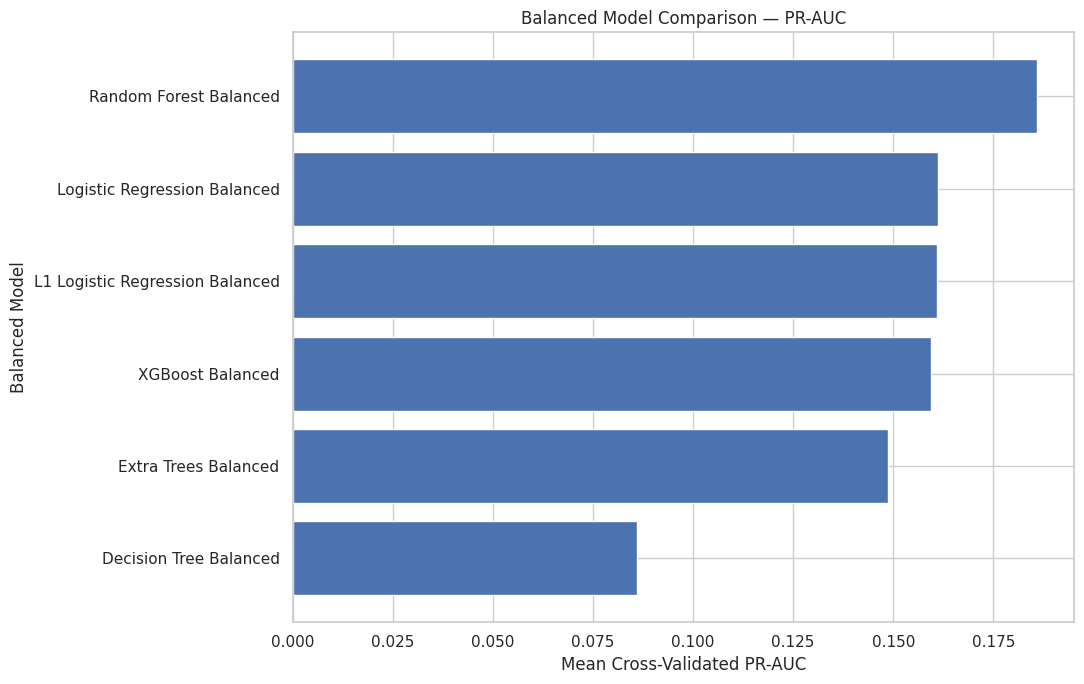

In [78]:
# ============================================================
# PHASE 15: BALANCED MODEL PR-AUC
# ============================================================

plot_df = (
    balanced_cv_df
    .sort_values(
        "PR_AUC_Mean",
        ascending=True
    )
)


plt.figure(
    figsize=(11, 7)
)


plt.barh(
    plot_df["Model"],
    plot_df["PR_AUC_Mean"]
)


plt.xlabel(
    "Mean Cross-Validated PR-AUC"
)

plt.ylabel(
    "Balanced Model"
)

plt.title(
    "Balanced Model Comparison — PR-AUC"
)

plt.tight_layout()

plt.show()

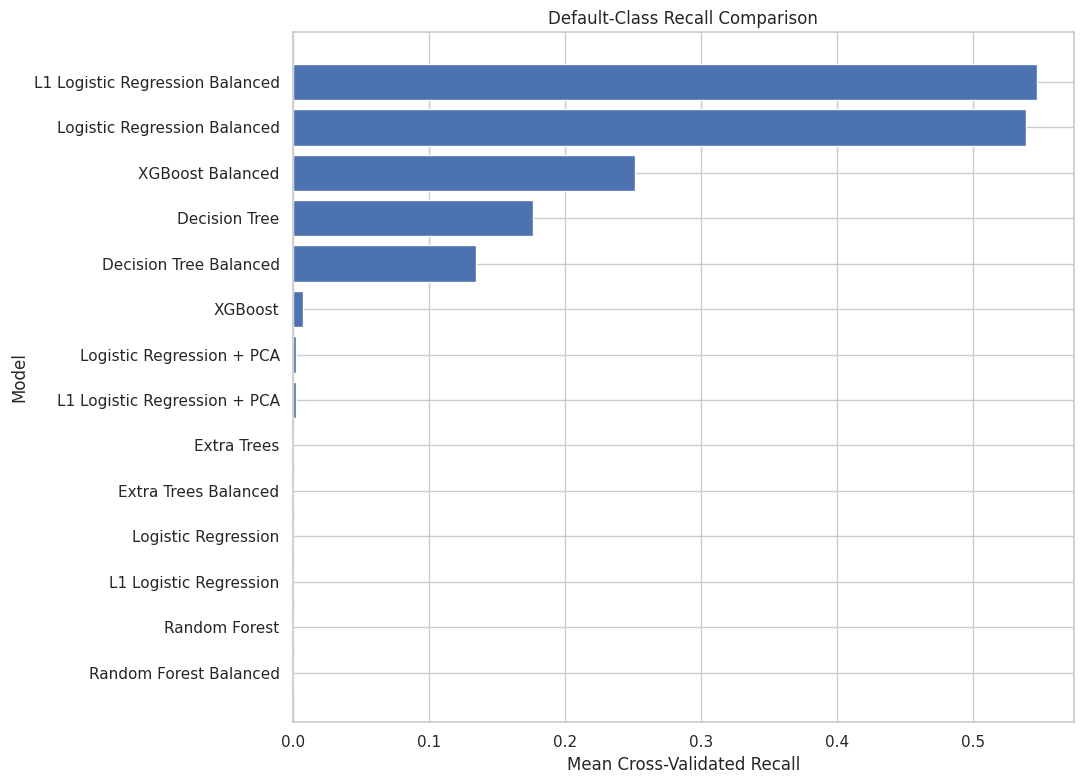

In [79]:
# ============================================================
# PHASE 15: RECALL COMPARISON
# ============================================================

recall_plot_df = (
    imbalance_comparison
    .sort_values(
        "Recall_Mean",
        ascending=True
    )
)


plt.figure(
    figsize=(11, 8)
)


plt.barh(
    recall_plot_df["Model"],
    recall_plot_df["Recall_Mean"]
)


plt.xlabel(
    "Mean Cross-Validated Recall"
)

plt.ylabel(
    "Model"
)

plt.title(
    "Default-Class Recall Comparison"
)

plt.tight_layout()

plt.show()

# Step 16 — Hyperparameter Tuning

Step 16 — Hyperparameter Tuning

I recommend taking these three models forward:

Random Forest Balanced
L1 Logistic Regression Balanced
XGBoost Balanced

Why these three?

They give us three different modelling approaches:

Random Forest → bagging/tree ensemble
L1 Logistic → sparse/interpretable linear model
XGBoost → boosting/tree ensemble

We don't need both Logistic Balanced and L1 Logistic Balanced because their current results are extremely close.

In [80]:
# ============================================================
# PHASE 16: HYPERPARAMETER GRIDS
# ============================================================

rf_param_grid = {

    "model__n_estimators": [
        200,
        400
    ],

    "model__max_depth": [
        None,
        5,
        10
    ],

    "model__min_samples_leaf": [
        1,
        3,
        5
    ],

    "model__max_features": [
        "sqrt",
        "log2"
    ]
}


l1_logistic_param_grid = {

    "model__C": [
        0.01,
        0.1,
        1,
        10,
        100
    ]
}


xgb_param_grid = {

    "model__n_estimators": [
        200,
        400
    ],

    "model__learning_rate": [
        0.03,
        0.05,
        0.1
    ],

    "model__max_depth": [
        3,
        4,
        6
    ],

    "model__subsample": [
        0.8,
        1.0
    ],

    "model__colsample_bytree": [
        0.8,
        1.0
    ]
}


print("Hyperparameter grids created.")

Hyperparameter grids created.


In [81]:
# ============================================================
# PHASE 16: TUNING PIPELINES
# ============================================================

rf_balanced_pipeline = Pipeline(
    steps=[
        (
            "preprocessing",
            preprocessor_no_pca
        ),
        (
            "model",
            RandomForestClassifier(
                class_weight="balanced",
                n_jobs=-1,
                random_state=RANDOM_STATE
            )
        )
    ]
)


l1_logistic_balanced_pipeline = Pipeline(
    steps=[
        (
            "preprocessing",
            preprocessor_no_pca
        ),
        (
            "model",
            LogisticRegression(
                penalty="l1",
                solver="liblinear",
                class_weight="balanced",
                max_iter=2000,
                random_state=RANDOM_STATE
            )
        )
    ]
)


xgb_balanced_pipeline = Pipeline(
    steps=[
        (
            "preprocessing",
            preprocessor_no_pca
        ),
        (
            "model",
            XGBClassifier(
                scale_pos_weight=scale_pos_weight,
                objective="binary:logistic",
                eval_metric="logloss",
                n_jobs=-1,
                random_state=RANDOM_STATE
            )
        )
    ]
)


print("Tuning pipelines created.")

Tuning pipelines created.


In [82]:
# ============================================================
# PHASE 16: RANDOM FOREST HYPERPARAMETER TUNING
# ============================================================

rf_grid_search = GridSearchCV(
    estimator=rf_balanced_pipeline,
    param_grid=rf_param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=1
)

rf_grid_search.fit(
    X_train,
    y_train
)

print()
print("Random Forest tuning completed.")
print()
print("Best PR-AUC:")
print(
    round(
        rf_grid_search.best_score_,
        4
    )
)

print()
print("Best Parameters:")
print(
    rf_grid_search.best_params_
)

Fitting 5 folds for each of 36 candidates, totalling 180 fits

Random Forest tuning completed.

Best PR-AUC:
0.1904

Best Parameters:
{'model__max_depth': None, 'model__max_features': 'log2', 'model__min_samples_leaf': 5, 'model__n_estimators': 400}


In [83]:
# ============================================================
# PHASE 16: L1 LOGISTIC REGRESSION TUNING
# ============================================================

l1_logistic_grid_search = GridSearchCV(
    estimator=l1_logistic_balanced_pipeline,
    param_grid=l1_logistic_param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=1
)

l1_logistic_grid_search.fit(
    X_train,
    y_train
)

print()
print("L1 Logistic Regression tuning completed.")
print()
print("Best PR-AUC:")
print(
    round(
        l1_logistic_grid_search.best_score_,
        4
    )
)

print()
print("Best Parameters:")
print(
    l1_logistic_grid_search.best_params_
)

Fitting 5 folds for each of 5 candidates, totalling 25 fits

L1 Logistic Regression tuning completed.

Best PR-AUC:
0.1728

Best Parameters:
{'model__C': 0.01}


In [84]:
# ============================================================
# PHASE 16: XGBOOST HYPERPARAMETER TUNING
# ============================================================

xgb_grid_search = GridSearchCV(
    estimator=xgb_balanced_pipeline,
    param_grid=xgb_param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=1
)

xgb_grid_search.fit(
    X_train,
    y_train
)

print()
print("XGBoost tuning completed.")
print()
print("Best PR-AUC:")
print(
    round(
        xgb_grid_search.best_score_,
        4
    )
)

print()
print("Best Parameters:")
print(
    xgb_grid_search.best_params_
)

Fitting 5 folds for each of 72 candidates, totalling 360 fits

XGBoost tuning completed.

Best PR-AUC:
0.1811

Best Parameters:
{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.03, 'model__max_depth': 4, 'model__n_estimators': 200, 'model__subsample': 0.8}


In [85]:
# ============================================================
# PHASE 16: TUNED MODEL COMPARISON
# ============================================================

tuned_results = pd.DataFrame({

    "Model": [
        "Random Forest Balanced Tuned",
        "L1 Logistic Regression Balanced Tuned",
        "XGBoost Balanced Tuned"
    ],

    "CV_PR_AUC": [
        rf_grid_search.best_score_,
        l1_logistic_grid_search.best_score_,
        xgb_grid_search.best_score_
    ]
})


tuned_results = (
    tuned_results
    .sort_values(
        "CV_PR_AUC",
        ascending=False
    )
    .reset_index(drop=True)
)


print("Tuned Model Comparison")
print("=" * 70)

display(
    tuned_results
)

Tuned Model Comparison


,Model,CV_PR_AUC
0,Random Forest Balanced Tuned,0.190414
1,XGBoost Balanced Tuned,0.181059
2,L1 Logistic Regression Balanced Tuned,0.172789


In [86]:
# ============================================================
# PHASE 17: OUT-OF-FOLD PROBABILITIES
# ============================================================

from sklearn.model_selection import cross_val_predict
from sklearn.base import clone

tuned_models = {

    "Random Forest Balanced Tuned":
        rf_grid_search.best_estimator_,

    "XGBoost Balanced Tuned":
        xgb_grid_search.best_estimator_,

    "L1 Logistic Regression Balanced Tuned":
        l1_logistic_grid_search.best_estimator_
}


oof_predictions = {}

for model_name, model in tuned_models.items():

    print(
        f"Generating OOF probabilities for: {model_name}"
    )

    oof_predictions[model_name] = (
        cross_val_predict(
            clone(model),
            X_train,
            y_train,
            cv=cv,
            method="predict_proba",
            n_jobs=-1
        )[:, 1]
    )


print()
print("Out-of-fold probabilities generated successfully.")

for model_name, probabilities in oof_predictions.items():

    print(
        model_name,
        "->",
        len(probabilities),
        "predictions"
    )

Generating OOF probabilities for: Random Forest Balanced Tuned
Generating OOF probabilities for: XGBoost Balanced Tuned
Generating OOF probabilities for: L1 Logistic Regression Balanced Tuned

Out-of-fold probabilities generated successfully.
Random Forest Balanced Tuned -> 4800 predictions
XGBoost Balanced Tuned -> 4800 predictions
L1 Logistic Regression Balanced Tuned -> 4800 predictions


In [87]:
# ============================================================
# PHASE 17: THRESHOLD SEARCH
# ============================================================

threshold_values = np.arange(
    0.05,
    0.96,
    0.01
)

all_threshold_results = []


for model_name, probabilities in oof_predictions.items():

    for threshold in threshold_values:

        predictions = (
            probabilities >= threshold
        ).astype(int)

        precision = precision_score(
            y_train,
            predictions,
            zero_division=0
        )

        recall = recall_score(
            y_train,
            predictions,
            zero_division=0
        )

        f1 = f1_score(
            y_train,
            predictions,
            zero_division=0
        )

        all_threshold_results.append({

            "Model":
                model_name,

            "Threshold":
                threshold,

            "Precision":
                precision,

            "Recall":
                recall,

            "F1":
                f1
        })


threshold_results_df = pd.DataFrame(
    all_threshold_results
)


print("Threshold analysis completed.")

Threshold analysis completed.


In [88]:
# ============================================================
# PHASE 17: BEST THRESHOLD FOR EACH MODEL
# ============================================================

best_thresholds = (
    threshold_results_df
    .sort_values(
        ["Model", "F1"],
        ascending=[True, False]
    )
    .groupby(
        "Model",
        as_index=False
    )
    .first()
)


print("Best threshold for each tuned model")
print("=" * 80)

display(
    best_thresholds[
        [
            "Model",
            "Threshold",
            "Precision",
            "Recall",
            "F1"
        ]
    ]
)

Best threshold for each tuned model


,Model,Threshold,Precision,Recall,F1
0,L1 Logistic Regression Balanced Tuned,0.60,0.179848,0.430052,0.253629
1,Random Forest Balanced Tuned,0.32,0.204023,0.367876,0.262477
2,XGBoost Balanced Tuned,0.51,0.166667,0.401554,0.235562


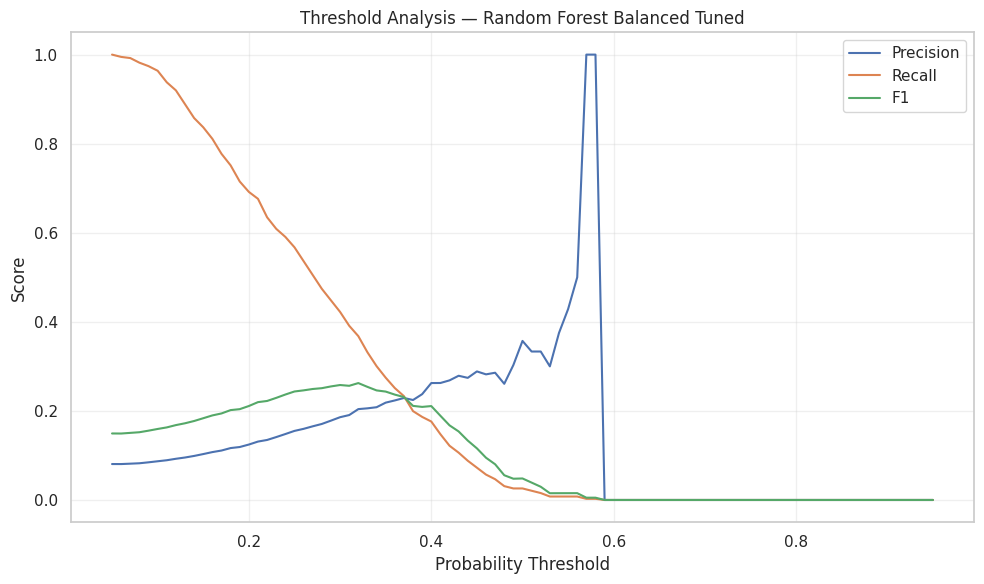

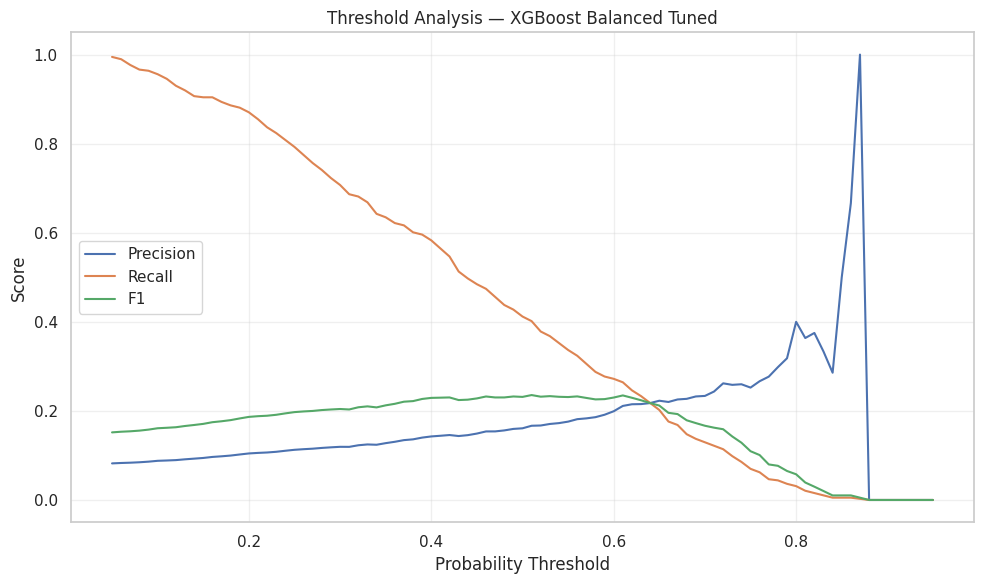

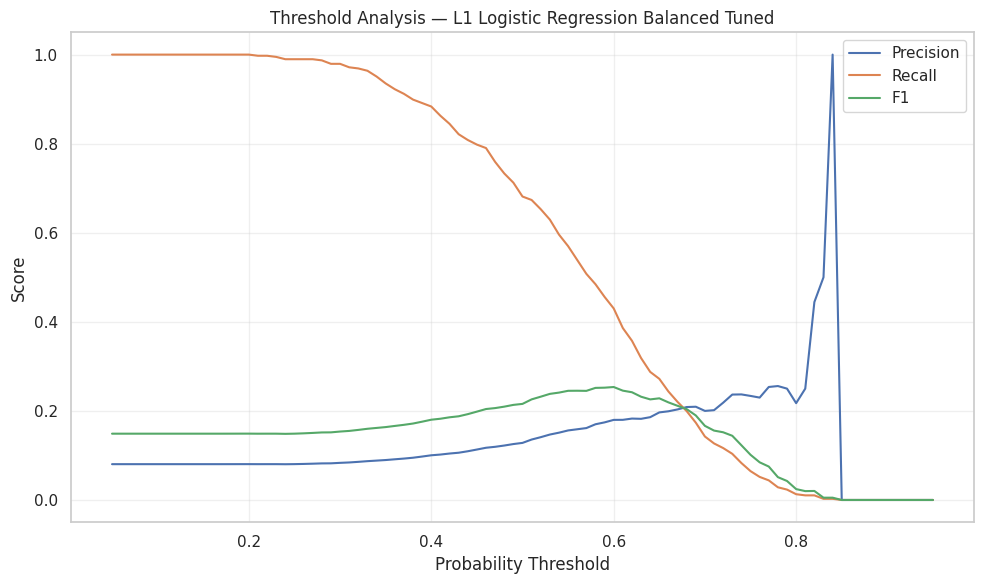

In [89]:
# ============================================================
# PHASE 17: THRESHOLD PERFORMANCE PLOT
# ============================================================

for model_name in tuned_models.keys():

    model_threshold_results = (
        threshold_results_df[
            threshold_results_df["Model"] == model_name
        ]
    )

    plt.figure(
        figsize=(10, 6)
    )

    plt.plot(
        model_threshold_results["Threshold"],
        model_threshold_results["Precision"],
        label="Precision"
    )

    plt.plot(
        model_threshold_results["Threshold"],
        model_threshold_results["Recall"],
        label="Recall"
    )

    plt.plot(
        model_threshold_results["Threshold"],
        model_threshold_results["F1"],
        label="F1"
    )

    plt.xlabel(
        "Probability Threshold"
    )

    plt.ylabel(
        "Score"
    )

    plt.title(
        f"Threshold Analysis — {model_name}"
    )

    plt.legend()

    plt.grid(
        True,
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()

In [90]:
# ============================================================
# PHASE 17: FINAL THRESHOLD COMPARISON
# ============================================================

threshold_model_comparison = (
    best_thresholds[
        [
            "Model",
            "Threshold",
            "Precision",
            "Recall",
            "F1"
        ]
    ]
    .sort_values(
        "F1",
        ascending=False
    )
    .reset_index(drop=True)
)


print("Best Threshold Performance — Tuned Models")
print("=" * 80)

display(
    threshold_model_comparison
)

Best Threshold Performance — Tuned Models


,Model,Threshold,Precision,Recall,F1
0,Random Forest Balanced Tuned,0.32,0.204023,0.367876,0.262477
1,L1 Logistic Regression Balanced Tuned,0.60,0.179848,0.430052,0.253629
2,XGBoost Balanced Tuned,0.51,0.166667,0.401554,0.235562


# Step 18 — Final Model Selection

# Phase 16 — Final Model Evaluation

The selected model is now fitted on the complete training dataset.

The untouched test set is used for the final unbiased evaluation.

Two classification thresholds are compared:

- Standard threshold = 0.50
- Optimized threshold selected using training out-of-fold predictions

Evaluation includes:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- PR-AUC
- Confusion matrix
- ROC curve
- Precision-Recall curve

In [91]:
# ============================================================
# PHASE 18: FINAL MODEL SELECTION
# ============================================================

best_model_name = "Random Forest Balanced Tuned"

best_branch = "No PCA"

optimal_threshold = 0.32

final_candidate_pipeline = (
    rf_grid_search.best_estimator_
)

print("Final candidate selected")
print("=" * 60)

print(
    "Model:",
    best_model_name
)

print(
    "Branch:",
    best_branch
)

print(
    "Optimal Threshold:",
    optimal_threshold
)

print(
    "Tuned CV PR-AUC:",
    round(
        rf_grid_search.best_score_,
        4
    )
)

Final candidate selected
Model: Random Forest Balanced Tuned
Branch: No PCA
Optimal Threshold: 0.32
Tuned CV PR-AUC: 0.1904


In [92]:
# ============================================================
# PHASE 18: FINAL MODEL FIT
# ============================================================

final_model = clone(
    final_candidate_pipeline
)

# Fit only on the complete training data
final_model.fit(
    X_train,
    y_train
)

# Generate probability predictions on untouched test data
test_probabilities = (
    final_model
    .predict_proba(X_test)[:, 1]
)

# Standard threshold
test_predictions_050 = (
    test_probabilities >= 0.50
).astype(int)

# Optimized threshold
test_predictions_optimal = (
    test_probabilities >= optimal_threshold
).astype(int)


print("Final model trained successfully.")
print()

print(
    "Model:",
    best_model_name
)

print(
    "Classification threshold:",
    optimal_threshold
)

print(
    "Test observations:",
    len(X_test)
)

Final model trained successfully.

Model: Random Forest Balanced Tuned
Classification threshold: 0.32
Test observations: 1200


In [93]:
# ============================================================
# PHASE 18: FINAL TEST EVALUATION
# ============================================================

final_evaluation = pd.DataFrame([

    {
        "Threshold": 0.50,

        "Accuracy":
            accuracy_score(
                y_test,
                test_predictions_050
            ),

        "Precision":
            precision_score(
                y_test,
                test_predictions_050,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_test,
                test_predictions_050,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_test,
                test_predictions_050,
                zero_division=0
            ),

        "ROC_AUC":
            roc_auc_score(
                y_test,
                test_probabilities
            ),

        "PR_AUC":
            average_precision_score(
                y_test,
                test_probabilities
            )
    },

    {
        "Threshold":
            optimal_threshold,

        "Accuracy":
            accuracy_score(
                y_test,
                test_predictions_optimal
            ),

        "Precision":
            precision_score(
                y_test,
                test_predictions_optimal,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_test,
                test_predictions_optimal,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_test,
                test_predictions_optimal,
                zero_division=0
            ),

        "ROC_AUC":
            roc_auc_score(
                y_test,
                test_probabilities
            ),

        "PR_AUC":
            average_precision_score(
                y_test,
                test_probabilities
            )
    }
])


print("FINAL TEST SET EVALUATION")
print("=" * 80)

display(
    final_evaluation
)

FINAL TEST SET EVALUATION


,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,0.50,0.920833,0.545455,0.0625,0.112150,0.725874,0.252233
1,0.32,0.833333,0.223404,0.4375,0.295775,0.725874,0.252233


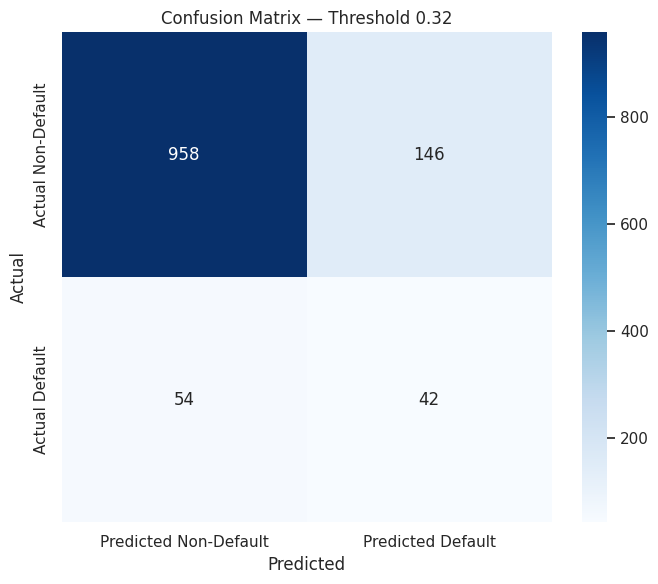

Confusion Matrix Summary
True Negatives : 958
False Positives: 146
False Negatives: 54
True Positives : 42


In [94]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    test_predictions_optimal
)

plt.figure(
    figsize=(7, 6)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Predicted Non-Default",
        "Predicted Default"
    ],
    yticklabels=[
        "Actual Non-Default",
        "Actual Default"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    f"Confusion Matrix — Threshold {optimal_threshold:.2f}"
)

plt.tight_layout()

plt.show()

# ============================================================
# CONFUSION MATRIX VALUES
# ============================================================

cm = confusion_matrix(
    y_test,
    test_predictions_optimal
)

tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix Summary")
print("=" * 50)

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

In [95]:
# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print(
    classification_report(
        y_test,
        test_predictions_optimal,
        target_names=[
            "Non-Default",
            "Default"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

 Non-Default       0.95      0.87      0.91      1104
     Default       0.22      0.44      0.30        96

    accuracy                           0.83      1200
   macro avg       0.59      0.65      0.60      1200
weighted avg       0.89      0.83      0.86      1200



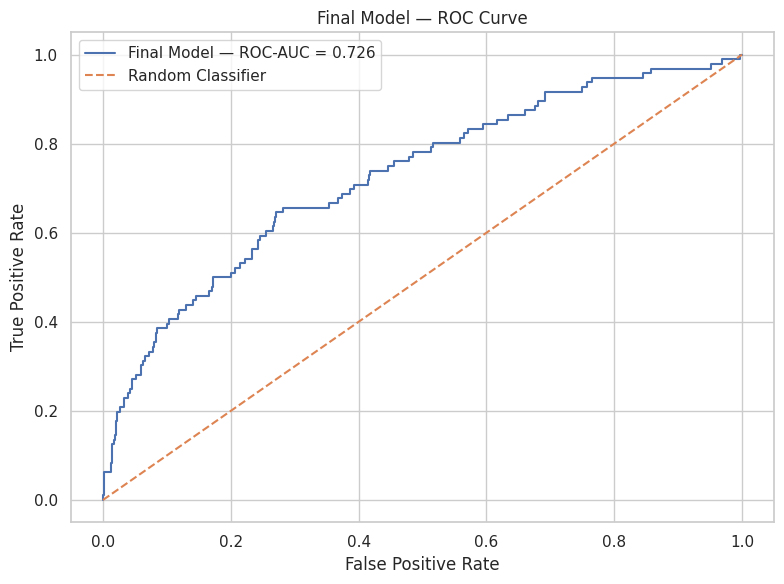

In [96]:
# ============================================================
# ROC CURVE
# ============================================================

fpr, tpr, _ = roc_curve(
    y_test,
    test_probabilities
)

roc_auc = roc_auc_score(
    y_test,
    test_probabilities
)

plt.figure(
    figsize=(8, 6)
)

plt.plot(
    fpr,
    tpr,
    label=f"Final Model — ROC-AUC = {roc_auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "Final Model — ROC Curve"
)

plt.legend()

plt.tight_layout()

plt.show()

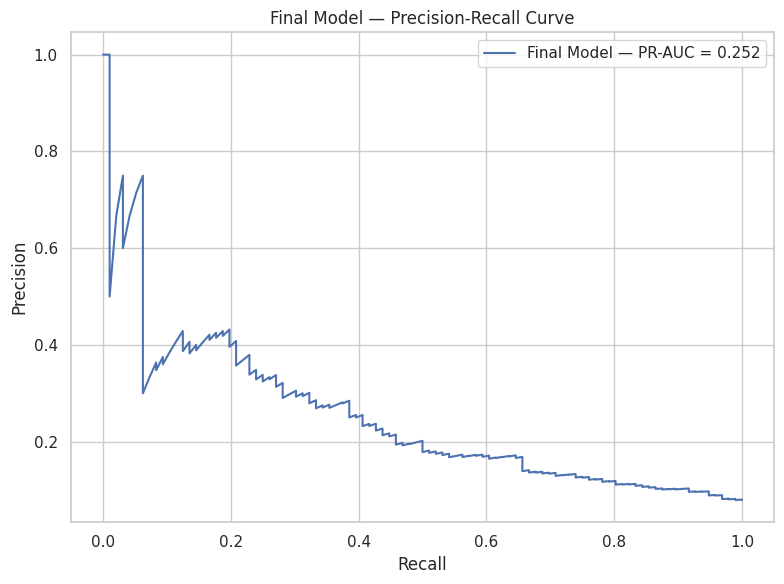

In [97]:
# ============================================================
# PRECISION-RECALL CURVE
# ============================================================

precision_curve, recall_curve, _ = (
    precision_recall_curve(
        y_test,
        test_probabilities
    )
)

pr_auc = average_precision_score(
    y_test,
    test_probabilities
)

plt.figure(
    figsize=(8, 6)
)

plt.plot(
    recall_curve,
    precision_curve,
    label=f"Final Model — PR-AUC = {pr_auc:.3f}"
)

plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "Final Model — Precision-Recall Curve"
)

plt.legend()

plt.tight_layout()

plt.show()

# Phase 17 — Feature Importance

Model explainability is important in a credit-risk application.

For tree-based models, feature importance can be used to identify attributes that contribute most strongly to prediction.

For Logistic Regression, model coefficients provide directional information.

If the selected model belongs to the PCA branch, the resulting components do not directly correspond to original business variables. In that case, PCA interpretation will be handled separately.

In [98]:
# ============================================================
# PHASE 19: FEATURE IMPORTANCE
# ============================================================

final_estimator = (
    final_model.named_steps["model"]
)

preprocessor = (
    final_model.named_steps["preprocessing"]
)

feature_names = (
    preprocessor
    .get_feature_names_out()
)

feature_importances = (
    final_estimator
    .feature_importances_
)

feature_importance_df = pd.DataFrame({

    "Feature": feature_names,

    "Importance": feature_importances
})


feature_importance_df = (
    feature_importance_df
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)


print("Top Feature Importances")
print("=" * 70)

display(
    feature_importance_df.head(20)
)

Top Feature Importances


,Feature,Importance
0,numeric__Average_Credit_Score,0.053623
1,numeric__Min_Credit_Score,0.046284
2,numeric__Max_Credit_Score,0.040811
3,numeric__Score_Source_2,0.039590
4,numeric__Employment_Years,0.034455
5,numeric__Employed_Days,0.034301
6,numeric__Score_Source_3,0.031042
7,numeric__Age_Years,0.027238
8,numeric__Age_Days,0.026876
9,numeric__Phone_Change,0.025839


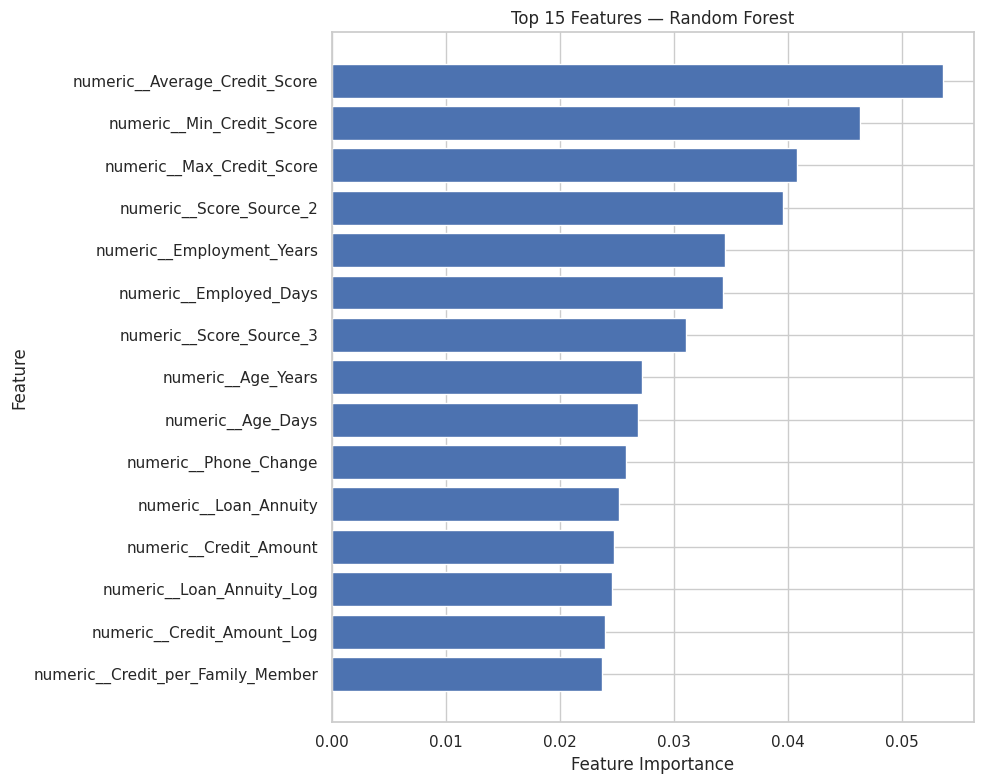

In [99]:
# ============================================================
# PHASE 19: TOP FEATURE IMPORTANCE PLOT
# ============================================================

top_features = (
    feature_importance_df
    .head(15)
    .sort_values(
        "Importance",
        ascending=True
    )
)

plt.figure(
    figsize=(10, 8)
)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel(
    "Feature Importance"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Top 15 Features — Random Forest"
)

plt.tight_layout()

plt.show()

In [100]:
# ============================================================
# PHASE 19: TOP FEATURES SUMMARY
# ============================================================

print("Top 10 Features Used by the Final Model")
print("=" * 70)

for i, row in feature_importance_df.head(10).iterrows():

    print(
        f"{i + 1:2d}. "
        f"{row['Feature']} "
        f"-> "
        f"{row['Importance']:.4f}"
    )

Top 10 Features Used by the Final Model
 1. numeric__Average_Credit_Score -> 0.0536
 2. numeric__Min_Credit_Score -> 0.0463
 3. numeric__Max_Credit_Score -> 0.0408
 4. numeric__Score_Source_2 -> 0.0396
 5. numeric__Employment_Years -> 0.0345
 6. numeric__Employed_Days -> 0.0343
 7. numeric__Score_Source_3 -> 0.0310
 8. numeric__Age_Years -> 0.0272
 9. numeric__Age_Days -> 0.0269
10. numeric__Phone_Change -> 0.0258


In [101]:
# ============================================================
# PHASE 19: PERMUTATION IMPORTANCE
# ============================================================

from sklearn.inspection import permutation_importance

# ------------------------------------------------------------
# Step 1: Extract the fitted preprocessing and final estimator
# ------------------------------------------------------------

final_preprocessor = (
    final_model.named_steps["preprocessing"]
)

final_estimator = (
    final_model.named_steps["model"]
)


# ------------------------------------------------------------
# Step 2: Transform the test data using the fitted preprocessor
# ------------------------------------------------------------

X_test_transformed = (
    final_preprocessor.transform(X_test)
)


# ------------------------------------------------------------
# Step 3: Calculate permutation importance
# ------------------------------------------------------------

permutation_result = permutation_importance(

    final_estimator,

    X_test_transformed,

    y_test,

    scoring="average_precision",

    n_repeats=10,

    random_state=RANDOM_STATE,

    n_jobs=-1
)


# ------------------------------------------------------------
# Step 4: Create feature-importance dataframe
# ------------------------------------------------------------

permutation_importance_df = pd.DataFrame({

    "Feature":
        feature_names,

    "Importance_Mean":
        permutation_result.importances_mean,

    "Importance_STD":
        permutation_result.importances_std
})


# ------------------------------------------------------------
# Step 5: Sort by importance
# ------------------------------------------------------------

permutation_importance_df = (

    permutation_importance_df

    .sort_values(
        "Importance_Mean",
        ascending=False
    )

    .reset_index(drop=True)
)


print("Top Permutation Importances")
print("=" * 70)

display(
    permutation_importance_df.head(20)
)

Top Permutation Importances


,Feature,Importance_Mean,Importance_STD
0,numeric__Average_Credit_Score,0.026440,0.012187
1,numeric__Score_Source_3,0.020498,0.006155
2,numeric__Max_Credit_Score,0.019149,0.010696
3,numeric__Min_Credit_Score,0.019047,0.010952
4,numeric__Phone_Change,0.015604,0.007929
5,numeric__Credit_Score_Range,0.014455,0.003860
6,numeric__Client_Income,0.013674,0.002103
7,numeric__Score_Source_2,0.012982,0.005771
8,numeric__Population_Region_Relative,0.012674,0.002983
9,numeric__Credit_Amount,0.011563,0.005886


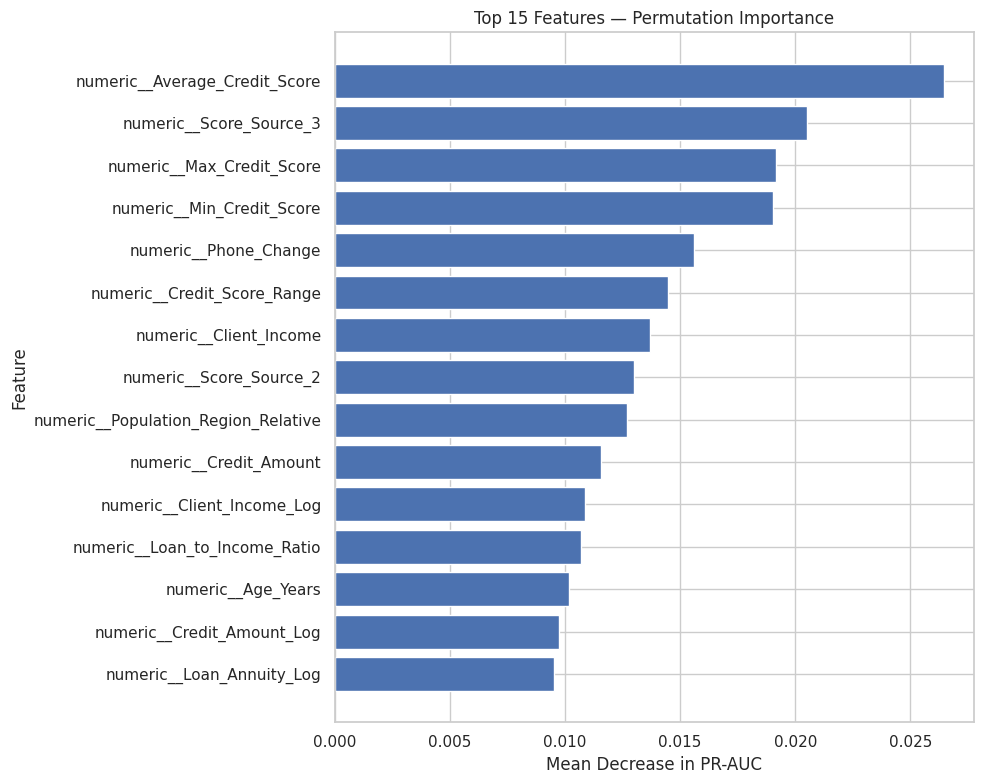

In [102]:
# ============================================================
# PHASE 19: PERMUTATION IMPORTANCE PLOT
# ============================================================

top_permutation = (

    permutation_importance_df

    .head(15)

    .sort_values(
        "Importance_Mean",
        ascending=True
    )
)


plt.figure(
    figsize=(10, 8)
)


plt.barh(

    top_permutation["Feature"],

    top_permutation["Importance_Mean"]

)


plt.xlabel(
    "Mean Decrease in PR-AUC"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Top 15 Features — Permutation Importance"
)

plt.tight_layout()

plt.show()

Phase 20 — New Applicant Prediction Demo

This is useful for your BITS project because it demonstrates how the trained model can be used on a hypothetical new loan applicant.

However, there is an important issue here:

Your final model expects the same raw input columns used by X_train, including all preprocessing and engineered variables.

We should not manually create a random dictionary of arbitrary features because that can easily cause:

missing-column errors
wrong data types
incorrect transformations
inconsistent preprocessing

Instead, we should use the actual columns from your training dataset.

In [103]:
# ============================================================
# PHASE 20: CHECK REQUIRED APPLICANT FEATURES
# ============================================================

print("Number of input features required:", X_train.shape[1])

print()
print("Required input columns:")
print("=" * 70)

for i, column in enumerate(X_train.columns, start=1):

    print(
        f"{i:3d}. {column}"
    )

Number of input features required: 60

Required input columns:
  1. Client_Income
  2. Car_Owned
  3. Bike_Owned
  4. Active_Loan
  5. House_Own
  6. Child_Count
  7. Credit_Amount
  8. Loan_Annuity
  9. Accompany_Client
 10. Client_Income_Type
 11. Client_Education
 12. Client_Marital_Status
 13. Client_Gender
 14. Loan_Contract_Type
 15. Client_Housing_Type
 16. Population_Region_Relative
 17. Age_Days
 18. Employed_Days
 19. Registration_Days
 20. ID_Days
 21. Own_House_Age
 22. Homephone_Tag
 23. Workphone_Working
 24. Client_Occupation
 25. Client_Family_Members
 26. Cleint_City_Rating
 27. Application_Process_Day
 28. Application_Process_Hour
 29. Client_Permanent_Match_Tag
 30. Client_Contact_Work_Tag
 31. Type_Organization
 32. Score_Source_1
 33. Score_Source_2
 34. Score_Source_3
 35. Social_Circle_Default
 36. Phone_Change
 37. Credit_Bureau
 38. Age_Years
 39. Employment_Years
 40. Registration_Years
 41. ID_Change_Years
 42. Loan_to_Income_Ratio
 43. Annuity_to_Income_Rati

In [104]:
# ============================================================
# PHASE 20A: IMPORTS AND DEFAULT SETTINGS
# ============================================================

import numpy as np
import pandas as pd

print("Phase 20 prediction environment ready.")
#print("Required model inputs:", X_train.shape[1])
#print("Classification threshold:", round(float(optimal_threshold), 3))

Phase 20 prediction environment ready.


In [105]:
# ============================================================
# PHASE 20B: PREPARE NEW APPLICANT
# ============================================================

def prepare_applicant_data(
    client_income=750000,
    credit_amount=1000000,
    loan_annuity=50000,
    age_years=35,
    employment_years=8,
    child_count=0,
    family_members=2,
    score_source_1=None,
    score_source_2=None,
    score_source_3=None
):
    """
    Create a complete 60-feature applicant record.

    User supplies only the most important applicant information.
    Remaining variables receive sensible training-data-based
    defaults.

    Credit scores are optional and should normally be in the
    range 0 to 1.
    """

    # --------------------------------------------------------
    # Validate numerical inputs
    # --------------------------------------------------------

    if client_income <= 0:
        raise ValueError(
            "Annual income must be greater than 0."
        )

    if credit_amount <= 0:
        raise ValueError(
            "Loan amount must be greater than 0."
        )

    if loan_annuity <= 0:
        raise ValueError(
            "Loan annuity must be greater than 0."
        )

    if not 18 <= age_years <= 100:
        raise ValueError(
            "Age must be between 18 and 100 years."
        )

    if not 0 <= employment_years <= age_years:
        raise ValueError(
            "Employment years must be between 0 and age."
        )

    if child_count < 0:
        raise ValueError(
            "Child count cannot be negative."
        )

    if family_members < 1:
        raise ValueError(
            "Family members must be at least 1."
        )

    if child_count > family_members:
        raise ValueError(
            "Child count cannot exceed family members."
        )

    # --------------------------------------------------------
    # Validate credit scores
    # --------------------------------------------------------

    scores = {
        "Score_Source_1": score_source_1,
        "Score_Source_2": score_source_2,
        "Score_Source_3": score_source_3
    }

    for name, value in scores.items():

        if value is not None:

            if not 0 <= value <= 1:

                raise ValueError(
                    f"{name} must be between 0 and 1."
                )

    # --------------------------------------------------------
    # Start with all required training columns
    # --------------------------------------------------------

    applicant = pd.DataFrame(
        np.nan,
        index=[0],
        columns=X_train.columns
    )

    # --------------------------------------------------------
    # Data-driven defaults
    #
    # Numeric features -> training median
    # Categorical features -> training mode
    # --------------------------------------------------------

    for column in X_train.columns:

        if column in categorical_features_final:

            mode_values = (
                X_train[column]
                .dropna()
                .mode()
            )

            if len(mode_values) > 0:

                applicant.loc[
                    0,
                    column
                ] = mode_values.iloc[0]

        else:

            median_value = (
                pd.to_numeric(
                    X_train[column],
                    errors="coerce"
                ).median()
            )

            if pd.notna(median_value):

                applicant.loc[
                    0,
                    column
                ] = median_value

    # --------------------------------------------------------
    # USER-PROVIDED RAW FEATURES
    # --------------------------------------------------------

    applicant.loc[
        0,
        "Client_Income"
    ] = client_income

    applicant.loc[
        0,
        "Credit_Amount"
    ] = credit_amount

    applicant.loc[
        0,
        "Loan_Annuity"
    ] = loan_annuity

    applicant.loc[
        0,
        "Child_Count"
    ] = child_count

    applicant.loc[
        0,
        "Client_Family_Members"
    ] = family_members

    # --------------------------------------------------------
    # Age and employment
    #
    # Original data stores these in day-based form.
    # The notebook derives year-based features from them.
    # --------------------------------------------------------

    applicant.loc[
        0,
        "Age_Days"
    ] = -(age_years * 365.25)

    applicant.loc[
        0,
        "Employed_Days"
    ] = -(employment_years * 365.25)

    applicant.loc[
        0,
        "Age_Years"
    ] = age_years

    applicant.loc[
        0,
        "Employment_Years"
    ] = employment_years

    # --------------------------------------------------------
    # CREDIT SCORES
    # --------------------------------------------------------

    applicant.loc[
        0,
        "Score_Source_1"
    ] = score_source_1

    applicant.loc[
        0,
        "Score_Source_2"
    ] = score_source_2

    applicant.loc[
        0,
        "Score_Source_3"
    ] = score_source_3

    valid_scores = pd.Series(
        [
            score_source_1,
            score_source_2,
            score_source_3
        ],
        dtype="float64"
    ).dropna()

    # --------------------------------------------------------
    # Credit-score aggregate features
    # --------------------------------------------------------

    if len(valid_scores) > 0:

        applicant.loc[
            0,
            "Average_Credit_Score"
        ] = valid_scores.mean()

        applicant.loc[
            0,
            "Min_Credit_Score"
        ] = valid_scores.min()

        applicant.loc[
            0,
            "Max_Credit_Score"
        ] = valid_scores.max()

        applicant.loc[
            0,
            "Credit_Score_Range"
        ] = (
            valid_scores.max()
            - valid_scores.min()
        )

        applicant.loc[
            0,
            "Available_Credit_Scores"
        ] = len(valid_scores)

    else:

        applicant.loc[
            0,
            "Average_Credit_Score"
        ] = np.nan

        applicant.loc[
            0,
            "Min_Credit_Score"
        ] = np.nan

        applicant.loc[
            0,
            "Max_Credit_Score"
        ] = np.nan

        applicant.loc[
            0,
            "Credit_Score_Range"
        ] = np.nan

        applicant.loc[
            0,
            "Available_Credit_Scores"
        ] = 0

    # --------------------------------------------------------
    # Missingness indicators
    # --------------------------------------------------------

    applicant.loc[
        0,
        "Score_Source_1_Missing"
    ] = int(score_source_1 is None)

    applicant.loc[
        0,
        "Score_Source_3_Missing"
    ] = int(score_source_3 is None)

    # --------------------------------------------------------
    # Financial ratios
    # --------------------------------------------------------

    applicant.loc[
        0,
        "Loan_to_Income_Ratio"
    ] = (
        credit_amount / client_income
    )

    applicant.loc[
        0,
        "Annuity_to_Income_Ratio"
    ] = (
        loan_annuity / client_income
    )

    applicant.loc[
        0,
        "Credit_per_Family_Member"
    ] = (
        credit_amount / family_members
    )

    applicant.loc[
        0,
        "Children_to_Family_Ratio"
    ] = (
        child_count / family_members
    )

    # --------------------------------------------------------
    # Log transformations
    # --------------------------------------------------------

    applicant.loc[
        0,
        "Client_Income_Log"
    ] = np.log1p(
        max(client_income, 0)
    )

    applicant.loc[
        0,
        "Credit_Amount_Log"
    ] = np.log1p(
        max(credit_amount, 0)
    )

    applicant.loc[
        0,
        "Loan_Annuity_Log"
    ] = np.log1p(
        max(loan_annuity, 0)
    )

    # --------------------------------------------------------
    # Application hour
    #
    # Default = 12 noon
    # --------------------------------------------------------

    default_application_hour = 12

    applicant.loc[
        0,
        "Application_Process_Hour"
    ] = default_application_hour

    applicant.loc[
        0,
        "Application_Hour_Sin"
    ] = np.sin(
        2 * np.pi
        * default_application_hour
        / 24
    )

    applicant.loc[
        0,
        "Application_Hour_Cos"
    ] = np.cos(
        2 * np.pi
        * default_application_hour
        / 24
    )

    # --------------------------------------------------------
    # Final column order
    # --------------------------------------------------------

    applicant = applicant[
        X_train.columns
    ]

    return applicant

In [106]:
# ============================================================
# PHASE 20C: NEW APPLICANT PREDICTION
# ============================================================

def predict_new_applicant(
    client_income=750000,
    credit_amount=1000000,
    loan_annuity=50000,
    age_years=35,
    employment_years=8,
    child_count=0,
    family_members=2,
    score_source_1=None,
    score_source_2=None,
    score_source_3=None
):
    """
    Predict default probability for a new applicant.
    """

    applicant_data = prepare_applicant_data(

        client_income=client_income,

        credit_amount=credit_amount,

        loan_annuity=loan_annuity,

        age_years=age_years,

        employment_years=employment_years,

        child_count=child_count,

        family_members=family_members,

        score_source_1=score_source_1,

        score_source_2=score_source_2,

        score_source_3=score_source_3
    )

    # --------------------------------------------------------
    # Model prediction
    # --------------------------------------------------------

    probability = (
        final_model
        .predict_proba(
            applicant_data
        )[0, 1]
    )

    # --------------------------------------------------------
    # Apply previously selected threshold
    # --------------------------------------------------------

    prediction = int(
        probability >= optimal_threshold
    )

    if prediction == 1:

        risk_decision = (
            "Higher Default Risk"
        )

    else:

        risk_decision = (
            "Lower Default Risk"
        )

    # --------------------------------------------------------
    # Result
    # --------------------------------------------------------

    result = pd.DataFrame({

        "Default_Probability": [
            round(probability, 4)
        ],

        "Default_Probability_%": [
            round(probability * 100, 2)
        ],

        "Classification_Threshold": [
            round(
                float(optimal_threshold),
                3
            )
        ],

        "Predicted_Default": [
            prediction
        ],

        "Risk_Decision": [
            risk_decision
        ]

    })

    return applicant_data, result

In [107]:
# ============================================================
# PHASE 20D: INTERACTIVE NEW APPLICANT DEMO
# ============================================================

def get_float_input(
    prompt,
    default,
    minimum=None,
    maximum=None
):
    """
    Read a numeric input with a default value.
    """

    while True:

        user_input = input(
            f"{prompt} [{default}]: "
        ).strip()

        if user_input == "":
            value = default

        else:

            try:
                value = float(user_input)

            except ValueError:

                print(
                    "Please enter a valid number."
                )

                continue

        if minimum is not None and value < minimum:

            print(
                f"Value must be >= {minimum}."
            )

            continue

        if maximum is not None and value > maximum:

            print(
                f"Value must be <= {maximum}."
            )

            continue

        return value


def get_optional_score(
    prompt
):
    """
    Credit scores are optional.
    Blank input means unavailable.
    """

    while True:

        user_input = input(
            f"{prompt} [blank = unavailable]: "
        ).strip()

        if user_input == "":
            return None

        try:

            value = float(user_input)

        except ValueError:

            print(
                "Please enter a number between 0 and 1."
            )

            continue

        if not 0 <= value <= 1:

            print(
                "Credit score must be between 0 and 1."
            )

            continue

        return value


print()
print("=" * 70)
print("NEW LOAN APPLICANT PREDICTION")
print("=" * 70)

print()
print(
    "Press Enter to use the sensible default shown in brackets."
)

print()
print("FINANCIAL INFORMATION")
print("-" * 70)

client_income = get_float_input(
    "Annual income",
    750000,
    minimum=1
)

credit_amount = get_float_input(
    "Loan / credit amount",
    1000000,
    minimum=1
)

loan_annuity = get_float_input(
    "Annual loan annuity / expected payment",
    50000,
    minimum=1
)

print()
print("PERSONAL INFORMATION")
print("-" * 70)

age_years = get_float_input(
    "Age in years",
    35,
    minimum=18,
    maximum=100
)

employment_years = get_float_input(
    "Employment duration in years",
    8,
    minimum=0,
    maximum=100
)

child_count = get_float_input(
    "Number of children",
    0,
    minimum=0
)

family_members = get_float_input(
    "Number of family members",
    2,
    minimum=1
)

if child_count > family_members:

    print()
    print(
        "Child count cannot exceed family members."
    )

    raise ValueError(
        "Please rerun the cell with valid family information."
    )

print()
print("CREDIT SCORE INFORMATION")
print("-" * 70)

print(
    "Credit scores should normally be entered as values between 0 and 1."
)

score_source_1 = get_optional_score(
    "Credit Score Source 1"
)

score_source_2 = get_optional_score(
    "Credit Score Source 2"
)

score_source_3 = get_optional_score(
    "Credit Score Source 3"
)


# ------------------------------------------------------------
# Make prediction
# ------------------------------------------------------------

applicant_data, prediction_result = (
    predict_new_applicant(

        client_income=client_income,

        credit_amount=credit_amount,

        loan_annuity=loan_annuity,

        age_years=age_years,

        employment_years=employment_years,

        child_count=int(child_count),

        family_members=int(family_members),

        score_source_1=score_source_1,

        score_source_2=score_source_2,

        score_source_3=score_source_3
    )
)


# ------------------------------------------------------------
# Display result
# ------------------------------------------------------------

print()
print("=" * 70)
print("PREDICTION RESULT")
print("=" * 70)

display(
    prediction_result
)


# ------------------------------------------------------------
# Display key applicant information
# ------------------------------------------------------------

print()
print("APPLICANT SUMMARY")
print("-" * 70)

summary = pd.DataFrame({

    "Input": [
        "Annual Income",
        "Loan Amount",
        "Loan Annuity",
        "Age",
        "Employment Years",
        "Children",
        "Family Members",
        "Credit Score 1",
        "Credit Score 2",
        "Credit Score 3"
    ],

    "Value": [
        client_income,
        credit_amount,
        loan_annuity,
        age_years,
        employment_years,
        child_count,
        family_members,
        score_source_1,
        score_source_2,
        score_source_3
    ]



})

display(summary)


NEW LOAN APPLICANT PREDICTION

Press Enter to use the sensible default shown in brackets.

FINANCIAL INFORMATION
----------------------------------------------------------------------
Annual income [750000]: 
Loan / credit amount [1000000]: 
Annual loan annuity / expected payment [50000]: 

PERSONAL INFORMATION
----------------------------------------------------------------------
Age in years [35]: 
Employment duration in years [8]: 
Number of children [0]: 
Number of family members [2]: 

CREDIT SCORE INFORMATION
----------------------------------------------------------------------
Credit scores should normally be entered as values between 0 and 1.
Credit Score Source 1 [blank = unavailable]: 
Credit Score Source 2 [blank = unavailable]: 
Credit Score Source 3 [blank = unavailable]: 


/tmp/ipykernel_711/3058221930.py:121: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Alone' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  applicant.loc[
/tmp/ipykernel_711/3058221930.py:121: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Service' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  applicant.loc[
/tmp/ipykernel_711/3058221930.py:121: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Secondary' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  applicant.loc[
/tmp/ipykernel_711/3058221930.py:121: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pa


PREDICTION RESULT


,Default_Probability,Default_Probability_%,Classification_Threshold,Predicted_Default,Risk_Decision
0,0.189,18.9,0.32,0,Lower Default Risk



APPLICANT SUMMARY
----------------------------------------------------------------------


,Input,Value
0,Annual Income,750000.0
1,Loan Amount,1000000.0
2,Loan Annuity,50000.0
3,Age,35.0
4,Employment Years,8.0
5,Children,0.0
6,Family Members,2.0
7,Credit Score 1,NaN
8,Credit Score 2,NaN
9,Credit Score 3,NaN


Although the modelling workflow provides a complete classification framework, several limitations remain.

### 1. Dataset limitations

The model is based on historical application data. Changes in applicant behaviour, economic conditions or lending policies may reduce future performance.

### 2. Class imbalance

Default cases are substantially less frequent than non-default cases. Therefore, accuracy can be misleading and performance should be monitored using recall, precision, F1-score and PR-AUC.

### 3. Threshold dependence

The classification threshold determines the trade-off between identifying more defaulters and generating more false positives.

### 4. Interpretability

PCA improves dimensionality reduction but reduces direct interpretability because components represent combinations of transformed variables.

### 5. Fairness

Variables related to demographic characteristics should be evaluated carefully for potential disparate impact before deployment.

### 6. Probability calibration

Future work could evaluate whether predicted probabilities are well calibrated and apply calibration techniques if required.

### 7. Advanced modelling

Future experiments could evaluate additional boosting algorithms, ensemble methods or cost-sensitive learning.

### 8. Monitoring

A production model would require ongoing monitoring for:

- Data drift
- Concept drift
- Model performance degradation
- Calibration
- Class distribution changes
- Fairness metrics